# Shard-link diagnostics (Step-2 graph)

Stage-1 **semantic shards are already very pure** on labeled email GT; the bottleneck for campaign recovery is how shards connect in the **Step-2 shard graph**.

This notebook treats that graph as the main object: **which shard links exist**, what **evidence channels** they carry, and how **same-campaign** vs **cross-campaign** links differ (GT is used only to label edges for analysis, plus shard purity and oracle ceilings).

**Oracle / ceiling metrics** remain useful: they show the **maximum** homogeneity / completeness / V-measure achievable if merges followed GT, with (**A**) no graph constraint vs (**B**) only along existing Step-2 edges.

The open design question for **unsupervised** shard-edge bucketing is which links are **true bridges** vs **false bridges**.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_here = Path.cwd().resolve()
PROJECT_ROOT = _here if (_here / "pipeline_config.json").is_file() else _here.parent
assert (PROJECT_ROOT / "pipeline_config.json").is_file(), PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

STEP1_ASSIGNMENTS = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step1" / "semantic_shard_step1_assignments.csv"
STEP2_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step2_graph"
GT_JSON = PROJECT_ROOT / "data" / "groundtruth" / "ground_truth_merged.json"

OUT_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_oracle_headroom"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MIN_DOMINANT_FRAC_FOR_EDGE_LABEL = 0.7
ORACLE_PURITY_THRESHOLD = 1.0

COLOR_SAME = "#1f77b4"
COLOR_CROSS = "#ff7f0e"
COLOR_AMBIG = "#7f7f7f"


In [2]:
from IPython.display import Markdown, display

from analysis.utils.raw_gnn_notebook import load_ground_truth_structures
from analysis.utils.semantic_shard_oracle_headroom_helpers import (
    infer_cross_edge_channel_specs,
    plot_label_short,
    artifact_filtering_candidates,
    build_artifact_shard_frequency_maps,
    build_edge_analysis_dataframe,
    build_shard_gt_summary,
    build_shard_member_ids_index,
    cross_edge_channel_presence_summary,
    evidence_binary_column_specs,
    expand_labeled_edges_to_artifact_incidence,
    find_body_subject_semantic_columns,
    label_candidate_edges_taxonomy,
    load_step1_assignments,
    metrics_pure_shards_as_clusters,
    oracle_metrics_from_shard_map,
    oracle_scenarios_comparison_df,
    sample_cross_edges_for_channel_inspection,
    shard_purity_global_summary,
    summarize_artifact_link_induction,
    top_mixed_shards,
    write_oracle_headroom_summary_md,
    _shard_to_oracle_community_ids,
)
from analysis.utils.semantic_shard_step3_helpers import load_step2_artifacts

gt_label_map, _eid_row, _campaign_to_members = load_ground_truth_structures(GT_JSON)
assignments_df = load_step1_assignments(STEP1_ASSIGNMENTS)
nodes_df, edges_df, _candidates_df = load_step2_artifacts(STEP2_DIR)

print("labeled GT emails:", len(gt_label_map))
print("assignments rows:", len(assignments_df))
print("step2 edges:", len(edges_df))


labeled GT emails: 1472
assignments rows: 7333
step2 edges: 4390


## 1. Compact shard purity + oracle ceilings

**Shard purity:** external clustering metrics when each shard is one cluster (labeled emails only).

**Oracle A / B:** perfect same-campaign merging among shards that pass the purity threshold — **A** ignores the graph; **B** only merges along Step-2 edges. The gap is the **connectivity ceiling** imposed by the current candidate graph.

Below: key numbers only (detail CSVs still written to `OUT_DIR`), plus a small V-measure comparison chart.


### Clustering metrics (labeled emails)

,n_eval,homogeneity,completeness,v_measure,n_shards_with_labeled
0,1472,0.9994,0.5823,0.7359,384


### Shard-level purity (compact)

,n_shards_with_labeled,n_pure_shards,n_mixed_shards,frac_labeled_in_pure_shards,weighted_avg_dominant_fraction
0,384,383,1,0.9966,0.9993


Mixed labeled shards (see CSV): 1


...

### Oracle A vs B (graph constraint)

,n_eval,homogeneity,completeness,v_measure,coverage_gt,coverage_assignments,n_communities,n_shards,n_shards_merged_proxy
0,1472.0,0.9994,0.9952,0.9973,1.0,0.2007,2544.0,2895.0,351.0


,n_eval,homogeneity,completeness,v_measure,coverage_gt,coverage_assignments,n_communities,n_shards,n_shards_merged_proxy
0,1472.0,0.9994,0.7929,0.8842,1.0,0.2007,2640.0,2895.0,255.0


**B − A**

,completeness,v_measure,n_communities,n_shards_merged_proxy
0,-0.2024,-0.1131,96.0,-96.0


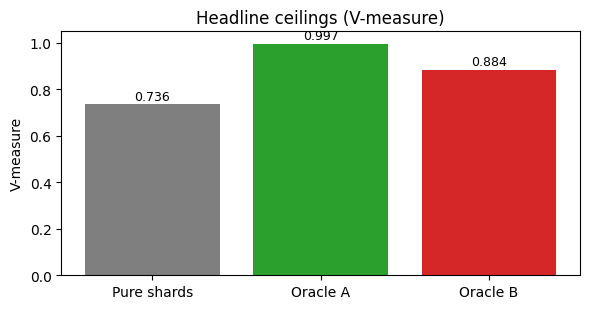

In [3]:
# Shard ↔ GT summary + oracle maps
shard_summary = build_shard_gt_summary(assignments_df, gt_label_map)
shard_summary.to_csv(OUT_DIR / "shard_purity_per_shard.csv", index=False)

pure_metrics = metrics_pure_shards_as_clusters(assignments_df, gt_label_map)
purity_global = shard_purity_global_summary(shard_summary, gt_label_map)
pd.DataFrame([{**pure_metrics, **purity_global}]).to_csv(
    OUT_DIR / "shard_purity_global_summary.csv", index=False
)

mixed_top = top_mixed_shards(shard_summary, n=20)
mixed_top.to_csv(OUT_DIR / "shard_purity_top_mixed_shards.csv", index=False)

map_a = _shard_to_oracle_community_ids(
    shard_summary, purity_threshold=ORACLE_PURITY_THRESHOLD, graph_edges=None
)
map_b = _shard_to_oracle_community_ids(
    shard_summary, purity_threshold=ORACLE_PURITY_THRESHOLD, graph_edges=edges_df
)
oracle_a = oracle_metrics_from_shard_map(assignments_df, map_a, gt_label_map)
oracle_b = oracle_metrics_from_shard_map(assignments_df, map_b, gt_label_map)
pd.DataFrame([oracle_a]).to_csv(OUT_DIR / "oracle_A_metrics.csv", index=False)
pd.DataFrame([oracle_b]).to_csv(OUT_DIR / "oracle_B_metrics.csv", index=False)

display(Markdown("### Clustering metrics (labeled emails)"))
display(pd.DataFrame([pure_metrics]).round(4))
display(Markdown("### Shard-level purity (compact)"))
display(pd.DataFrame([purity_global]).round(4))
print(f"Mixed labeled shards (see CSV): {int(purity_global.get('n_mixed_shards', 0))}")
display(mixed_top.head(5))

display(Markdown("### Oracle A vs B (graph constraint)"))
display(pd.DataFrame([oracle_a]).round(4))
display(pd.DataFrame([oracle_b]).round(4))
_delta_keys = ("completeness", "v_measure", "n_communities", "n_shards_merged_proxy")
_delta = {
    k: float(oracle_b[k]) - float(oracle_a[k])
    for k in _delta_keys
    if k in oracle_a and k in oracle_b and pd.notna(oracle_a[k]) and pd.notna(oracle_b[k])
}
display(Markdown("**B − A**"))
display(pd.DataFrame([_delta]).round(4))

cmp = oracle_scenarios_comparison_df(
    pure_shard_metrics=pure_metrics, oracle_a=oracle_a, oracle_b=oracle_b
)
cmp.to_csv(OUT_DIR / "oracle_ceiling_scenarios.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 3.2))
xs = ["Pure shards", "Oracle A", "Oracle B"]
ys = [pure_metrics["v_measure"], oracle_a["v_measure"], oracle_b["v_measure"]]
bars = ax.bar(xs, ys, color=[COLOR_AMBIG, "#2ca02c", "#d62728"])
ax.set_ylabel("V-measure")
ax.set_title("Headline ceilings (V-measure)")
ax.set_ylim(0, 1.05)
for b, v in zip(bars, ys):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


## 2. Central labeled shard-link table (`edge_analysis_df`)

Each row is one undirected Step-2 edge. **Ground truth** supplies `link_label` (**same** / **cross** / **ambiguous**) via shard dominant campaigns (same rules as before).

Boolean **`has_*`** columns mark **non-zero** shared-count infra channels, temporal overlap (or strong temporal score), optional V2 local-rank columns if you merge them in later, and separate body/subject semantics **only if** those columns exist on the edge table (standard Step-2 export is aggregate cosine only).


In [23]:
edges_tax = label_candidate_edges_taxonomy(
    edges_df,
    shard_summary,
    min_dominant_fraction=MIN_DOMINANT_FRAC_FOR_EDGE_LABEL,
)
edges_tax.to_csv(OUT_DIR / "candidate_edges_labeled_taxonomy.csv", index=False)

edge_analysis_df = build_edge_analysis_dataframe(edges_df, edges_tax)
edge_analysis_df.to_csv(OUT_DIR / "edge_analysis_df.csv", index=False)

print("edge_analysis_df:", edge_analysis_df.shape)
print("Columns (sample):", list(edge_analysis_df.columns[:18]), "...")
display(edge_analysis_df[["shard_a", "shard_b", "link_label", "n_evidence_channels"]].head(3))


edge_analysis_df: (4390, 59)
Columns (sample): ['shard_a', 'shard_b', 'centroid_cosine', 'shared_url_count', 'url_jaccard', 'shared_url_idf_sum', 'shared_url_n_cutoff_filtered', 'infra_contrib_url_pre_cap', 'infra_contrib_url', 'shared_sender_email_domain_count', 'sender_email_domain_jaccard', 'shared_sender_email_domain_idf_sum', 'shared_sender_email_domain_n_cutoff_filtered', 'infra_contrib_sender_email_domain_pre_cap', 'infra_contrib_sender_email_domain', 'shared_domain_count', 'domain_jaccard', 'shared_domain_idf_sum'] ...


,shard_a,shard_b,link_label,n_evidence_channels
0,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBl...,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMy...,ambiguous,2
1,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBl...,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBl...,ambiguous,2
2,noise_AAMkADJkZmFmMzliLTg5MTItNDQ2My1hM2Y3LTBl...,noise_AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMy...,ambiguous,4


## 3. Labeled-link composition

Quick counts of **same** / **cross** / **ambiguous**.


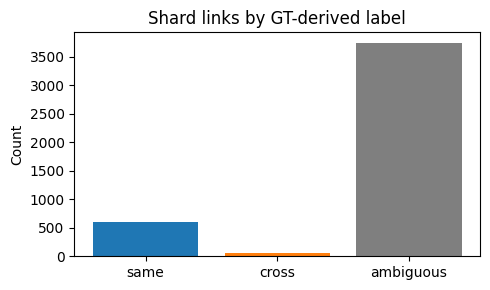

In [24]:
def _countplot_link_labels(df: pd.DataFrame) -> None:
    vc = df["link_label"].value_counts().reindex(["same", "cross", "ambiguous"]).fillna(0).astype(int)
    fig, ax = plt.subplots(figsize=(5, 3))
    colors = [COLOR_SAME, COLOR_CROSS, COLOR_AMBIG]
    ax.bar(vc.index.astype(str), vc.values, color=colors)
    ax.set_ylabel("Count")
    ax.set_title("Shard links by GT-derived label")
    plt.tight_layout()
    plt.show()


_countplot_link_labels(edge_analysis_df)


## 4. Shard-link evidence anatomy

**Prevalence is not trustworthiness** - a channel can be common on cross edges too - but this shows **what shard links are made of**.

Grouped bars: fraction of edges (within **same** vs **cross**) that activate each boolean channel. Ambiguous edges are excluded from these fractions.

Quick reading guide:
- In the grouped-bar plot, each bar is a **within-class fraction**. Example: `same=0.85` for Sender overlap means **85% of edges labeled `same`** have `has_sender_overlap=True`.
- This is `P(channel active | label)` (e.g., `P(sender overlap | same)`), **not** `P(label | channel active)`.
- In the difference plot, each bar is `fraction_same - fraction_cross` for that channel.
  - Positive: channel appears more often on same-campaign edges.
  - Negative: channel appears more often on cross-campaign edges.
  - Near zero: little separation between same and cross.
- Ambiguous edges are excluded in these comparisons; denominators are only labeled `same`/`cross` edges.


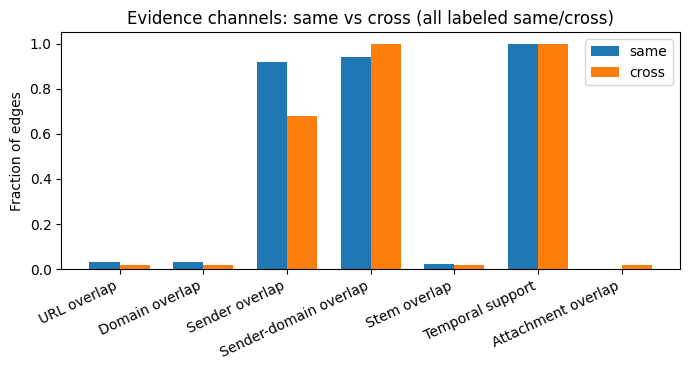

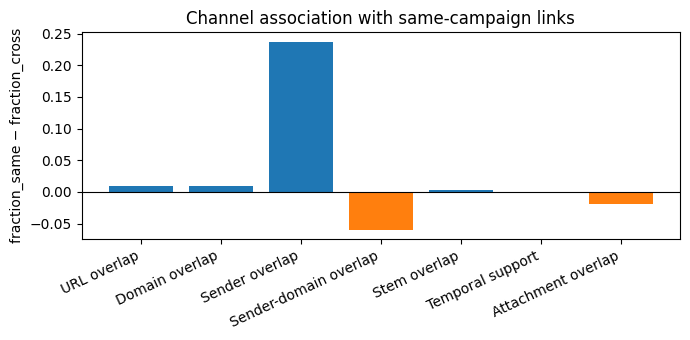

In [25]:
specs = evidence_binary_column_specs(edge_analysis_df)
labeled = edge_analysis_df[edge_analysis_df["link_label"].isin(["same", "cross"])].copy()

if not specs:
    display(Markdown("_No boolean evidence columns found._"))
else:
    def frac_active(sub: pd.DataFrame, col: str) -> float:
        if sub.empty or col not in sub.columns:
            return float("nan")
        return float(sub[col].astype(bool).mean())

    plot_labels = [s[0] for s in specs]
    plot_cols = [s[1] for s in specs]

    def plot_grouped(sub: pd.DataFrame, title: str) -> None:
        fs = [frac_active(sub[sub["link_label"] == "same"], c) for c in plot_cols]
        fc = [frac_active(sub[sub["link_label"] == "cross"], c) for c in plot_cols]
        x = np.arange(len(plot_labels))
        w = 0.36
        fig, ax = plt.subplots(figsize=(max(7, len(plot_labels) * 0.9), 3.8))
        ax.bar(x - w / 2, fs, width=w, label="same", color=COLOR_SAME)
        ax.bar(x + w / 2, fc, width=w, label="cross", color=COLOR_CROSS)
        ax.set_xticks(x)
        ax.set_xticklabels(plot_labels, rotation=25, ha="right")
        ax.set_ylabel("Fraction of edges")
        ax.set_ylim(0, 1.05)
        ax.legend()
        ax.set_title(title)
        plt.tight_layout()
        plt.show()

    plot_grouped(labeled, "Evidence channels: same vs cross (all labeled same/cross)")
    diff_vals = [
        frac_active(labeled[labeled["link_label"] == "same"], c)
        - frac_active(labeled[labeled["link_label"] == "cross"], c)
        for c in plot_cols
    ]
    fig, ax = plt.subplots(figsize=(max(7, len(plot_labels) * 0.9), 3.5))
    colors = [COLOR_SAME if d >= 0 else COLOR_CROSS for d in diff_vals]
    ax.bar(np.arange(len(plot_labels)), diff_vals, color=colors)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(np.arange(len(plot_labels)))
    ax.set_xticklabels(plot_labels, rotation=25, ha="right")
    ax.set_ylabel("fraction_same − fraction_cross")
    ax.set_title("Channel association with same-campaign links")
    plt.tight_layout()
    plt.show()


## 5. Number of active evidence channels per link

Do same-campaign links carry **more corroborating channels** than cross-campaign links? Count = sum of the boolean channels used for `n_evidence_channels` in §2.


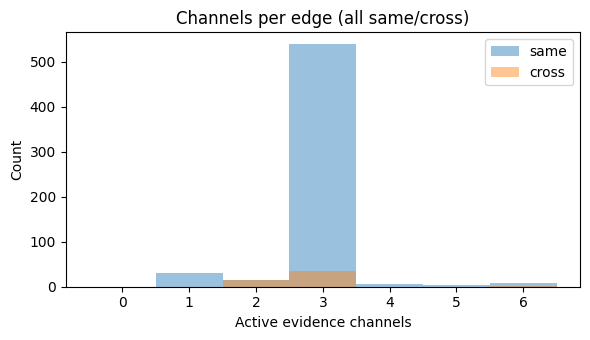

,group,mean_n_channels,n
0,same (all),2.942,603
1,cross (all),2.760,50


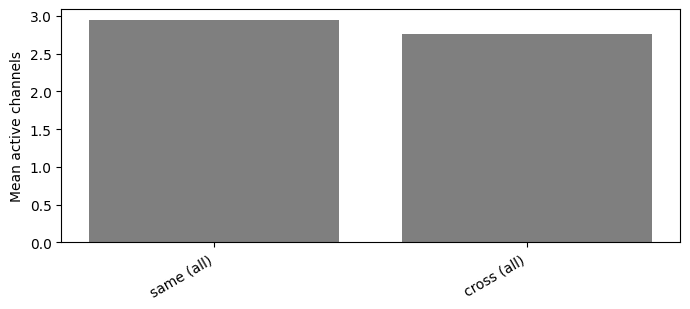

In [26]:
def plot_channel_count_hists(df: pd.DataFrame, title_suffix: str) -> None:
    sub = df[df["link_label"].isin(["same", "cross"])].copy()
    if sub.empty:
        display(Markdown("_No same/cross rows._"))
        return
    fig, ax = plt.subplots(figsize=(6, 3.5))
    bins = np.arange(-0.5, sub["n_evidence_channels"].max() + 1.5, 1)
    for lab, color in [("same", COLOR_SAME), ("cross", COLOR_CROSS)]:
        x = sub.loc[sub["link_label"] == lab, "n_evidence_channels"]
        ax.hist(x, bins=bins, alpha=0.45, label=lab, color=color, density=False)
    ax.set_xlabel("Active evidence channels")
    ax.set_ylabel("Count")
    ax.set_title(f"Channels per edge ({title_suffix})")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_channel_count_hists(edge_analysis_df, "all same/cross")

rows = []
for lab in ["same", "cross"]:
    sub_all = edge_analysis_df[edge_analysis_df["link_label"] == lab]
    rows.append(
        {
            "group": f"{lab} (all)",
            "mean_n_channels": float(sub_all["n_evidence_channels"].mean()) if len(sub_all) else float("nan"),
            "n": int(len(sub_all)),
        }
    )
mean_df = pd.DataFrame(rows)
display(mean_df.round(4))
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(mean_df["group"], mean_df["mean_n_channels"], color=COLOR_AMBIG)
ax.set_ylabel("Mean active channels")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 7. Optional feature distributions (same vs cross)

**Same vs cross** on a few scalars already on the edge table. Skips any missing column.

How to read these plots (easy version):
- Each histogram compares the distribution of one numeric feature for `same` edges vs `cross` edges.
- `same` means GT says both endpoint shards are from the same campaign; `cross` means different campaigns.
- The y-axis is **density** (`density=True`), so it shows shape/relative concentration, not raw edge counts.

What each plot means:
- **Semantic aggregate (centroid cosine):** higher values mean shard centroids are more semantically similar.
  - If the `same` curve is shifted right (or has a stronger right tail), that suggests semantic similarity helps identify same-campaign links.
  - Heavy overlap between `same` and `cross` means cosine alone is not a clean separator.
- **Infrastructure aggregate score:** combined overlap signal from infra channels.
  - If `same` is higher than `cross`, infra evidence supports same-campaign links.
  - If both overlap strongly, infra score is useful as a soft feature, but not a standalone threshold.

Practical interpretation:
- **Less overlap = better separation** between same and cross for that feature.
- **More overlap = weaker standalone signal**, so combine with other features/channels.


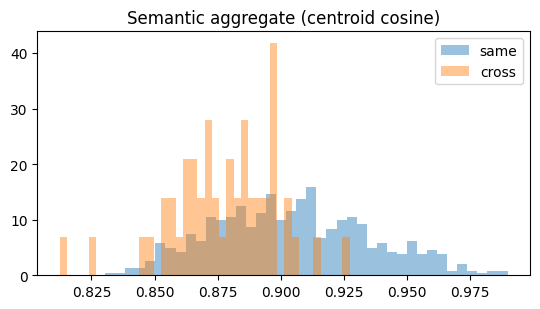

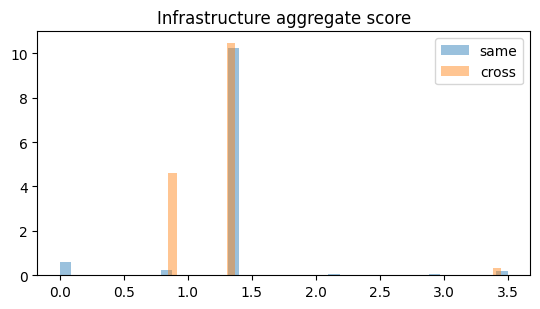

In [28]:
def _hist_same_cross(series_same, series_cross, title: str) -> None:
    fig, ax = plt.subplots(figsize=(5.5, 3.2))
    if len(series_same) or len(series_cross):
        bins = 40
        ax.hist(series_same.dropna(), bins=bins, alpha=0.45, label="same", color=COLOR_SAME, density=True)
        ax.hist(series_cross.dropna(), bins=bins, alpha=0.45, label="cross", color=COLOR_CROSS, density=True)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


sub = edge_analysis_df[edge_analysis_df["link_label"].isin(["same", "cross"])].copy()
same_m = sub["link_label"] == "same"
cross_m = sub["link_label"] == "cross"

for col, title in [
    ("semantic_aggregate", "Semantic aggregate (centroid cosine)"),
    ("infra_aggregate", "Infrastructure aggregate score"),
    ("v2_local_embeddedness_rank", "Local embeddedness rank (if present)"),
    ("v2_infra_dominance", "Infra dominance / hub signal (if present)"),
]:
    if col not in sub.columns:
        continue
    v = pd.to_numeric(sub[col], errors="coerce")
    _hist_same_cross(v[same_m], v[cross_m], title)


## 8. Inspectable cross-edge examples by evidence channel

For **cross-campaign** shard links only (`link_label == "cross"`), sample edges where a given infra channel fires (`has_*` flag). Ordering prioritizes **higher semantic aggregate**, then **stronger overlap** (shared count / IDF sum when present).

**Shared values** (e.g. actual overlapping URLs) are computed as the **intersection** of the two shards’ sets from `semantic_shard_step2_nodes.csv` when the corresponding `*_set` column exists. If that column is missing, the table still shows shard IDs, GT summaries, and overlap counts from the edge row.

**Email IDs:** Every **`external_id`** in each endpoint shard is shown: the table columns use one id per line, Jupyter wide cells are enabled via `display.max_colwidth`, and the text block below each example prints the **full** src/dst lists (no `+N more`). To cap lists again, pass a positive `max_member_ids_preview` into `sample_cross_edges_for_channel_inspection`.

Use this for manual review of **GT noise**, **generic features** (especially stems), and whether some channels should be **gated or downweighted** in unsupervised bucket design.


Cross-labeled edges: 50


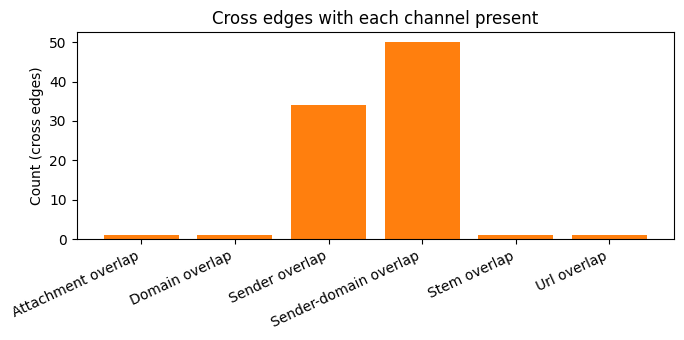

,channel,n_cross_with_channel,frac_of_cross
0,Attachment overlap,1,0.02
1,Domain overlap,1,0.02
2,Sender overlap,34,0.68
3,Sender-domain overlap,50,1.00
4,Stem overlap,1,0.02
5,Url overlap,1,0.02


### Attachment overlap

,src_shard,dst_shard,src_member_ids_preview,dst_member_ids_preview,src_dominant_campaign,dst_dominant_campaign,src_dominant_fraction,dst_dominant_fraction,src_size,dst_size,semantic_aggregate,infra_aggregate,shared_attachment_count,shared_attachment_idf_sum,shared_values_preview
0,shard_237,shard_652,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADnoZDlAAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP3MwAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP3cgAAAA==,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADoru8nQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP51QAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5rAAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5rwAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5sQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5sgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5uwAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5wQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5xgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5yQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5zQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP6EAAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP6EQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP6GgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP6LgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADtczP0AAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADtczPoQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADtczPqAAAAA==,41,206,1.0,1.0,3,18,0.8245,3.4483,3,22.7544,4be65f192a76921cd74d7757bc61474c6abef32a383396de8226af0dec6a316b; 52c2d5e741a5c1800099ad30198e15ec63d18e26d06952b48318c2e77a937b51; 8564174df3ad0dfbb047a68658bacf38ff37229162f7dca687f751c83a7adac7


shard_237 ↔ shard_652 | campaigns 41 vs 206 | sem=0.825 infra=3.448 | shared: 4be65f192a76921cd74d7757bc61474c6abef32a383396de8226af0dec6a316b; 52c2d5e741a5c1800099ad30198e15ec63d18e26d06952b48318c2e77a937b51; 8564174df3ad0dfbb047a68658bacf38ff37229162f7dca687f751c83a7adac7
  src external_ids (full):
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADnoZDlAAAAA==
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP3MwAAAA==
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP3cgAAAA==
  dst external_ids (full):
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADoru8nQAAAA==
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWM

### Domain overlap

...

,src_shard,dst_shard,src_member_ids_preview,dst_member_ids_preview,src_dominant_campaign,dst_dominant_campaign,src_dominant_fraction,dst_dominant_fraction,src_size,dst_size,semantic_aggregate,infra_aggregate,shared_stem_count,shared_stem_idf_sum,shared_values_preview
0,shard_237,shard_652,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADnoZDlAAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP3MwAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP3cgAAAA==,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADoru8nQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP51QAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5rAAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5rwAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5sQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5sgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5uwAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5wQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5xgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5yQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5zQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP6EAAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP6EQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP6GgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP6LgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADtczP0AAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADtczPoQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADtczPqAAAAA==,41,206,1.0,1.0,3,18,0.8245,3.4483,6,45.2856,/facebook; /facebook]; /information-dsgvo; /information-dsgvo]; /instagram (+1 more)


shard_237 ↔ shard_652 | campaigns 41 vs 206 | sem=0.825 infra=3.448 | shared: /facebook; /facebook]; /information-dsgvo; /information-dsgvo]; /instagram (+1 more)
  src external_ids (full):
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADnoZDlAAAAA==
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP3MwAAAA==
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP3cgAAAA==
  dst external_ids (full):
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADoru8nQAAAA==
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP51QAAAA=

### Url overlap

,src_shard,dst_shard,src_member_ids_preview,dst_member_ids_preview,src_dominant_campaign,dst_dominant_campaign,src_dominant_fraction,dst_dominant_fraction,src_size,dst_size,semantic_aggregate,infra_aggregate,shared_url_count,shared_url_idf_sum,shared_values_preview
0,shard_237,shard_652,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADnoZDlAAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP3MwAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP3cgAAAA==,AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADoru8nQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP51QAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5rAAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5rwAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5sQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5sgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5uwAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5wQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5xgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5yQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP5zQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP6EAAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP6EQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP6GgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP6LgAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADtczP0AAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADtczPoQAAAA==\nAQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADtczPqAAAAA==,41,206,1.0,1.0,3,18,0.8245,3.4483,8,60.4552,www.landkreis-osnabrueck.de/; www.landkreis-osnabrueck.de/]; www.landkreis-osnabrueck.de/facebook; www.landkreis-osnabrueck.de/facebook]; www.landkreis-osnabrueck.de/information-dsgvo (+3 more)


shard_237 ↔ shard_652 | campaigns 41 vs 206 | sem=0.825 infra=3.448 | shared: www.landkreis-osnabrueck.de/; www.landkreis-osnabrueck.de/]; www.landkreis-osnabrueck.de/facebook; www.landkreis-osnabrueck.de/facebook]; www.landkreis-osnabrueck.de/information-dsgvo (+3 more)
  src external_ids (full):
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADnoZDlAAAAA==
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP3MwAAAA==
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADsiP3cgAAAA==
  dst external_ids (full):
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZjgxZGIzYzRiNwBGAAADtqt2vzy4E0qn_gnFnZoyOgcAoujdSKU_hE_VWZWuokHqkgAAAgEMAAAAoujdSKU_hE_VWZWuokHqkgADoru8nQAAAA==
    AQMkADRlZjU3OTNlLTg0YmUtNGVjMi04M2MzLWMyZj

In [29]:
CROSS_INSPECTION_TOP_N = 12
CROSS_INSPECTION_MAX_VALUES = 5

_TEXT_PREVIEW_COLS = ("shared_values_preview", "src_member_ids_preview", "dst_member_ids_preview")

edge_cross = edge_analysis_df[edge_analysis_df["link_label"] == "cross"].copy()
_shard_member_ids = build_shard_member_ids_index(nodes_df)
n_cross = len(edge_cross)
print(f"Cross-labeled edges: {n_cross}")

ch_summary = cross_edge_channel_presence_summary(edge_cross)
if ch_summary.empty:
    display(Markdown("_No channel flags found on cross edges._"))
else:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(ch_summary["channel"], ch_summary["n_cross_with_channel"], color=COLOR_CROSS)
    ax.set_ylabel("Count (cross edges)")
    ax.set_title("Cross edges with each channel present")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
    display(ch_summary.round(4))

for spec in infer_cross_edge_channel_specs(edge_cross):
    display(Markdown(f"### {spec['title']}"))
    if spec["has_col"] not in edge_cross.columns:
        display(Markdown(f"_Skipping — column `{spec['has_col']}` not present._"))
        continue
    n_ch = int(edge_cross[spec["has_col"]].astype(bool).sum())
    if n_ch == 0:
        display(Markdown("_No cross edges with this channel._"))
        continue
    tab, note = sample_cross_edges_for_channel_inspection(
        edge_cross,
        shard_summary,
        nodes_df,
        spec,
        top_n=CROSS_INSPECTION_TOP_N,
        max_values_preview=CROSS_INSPECTION_MAX_VALUES,
    )
    if note:
        display(Markdown(f"*{note}*"))
    if tab.empty:
        continue
    num_cols = [c for c in tab.columns if c not in _TEXT_PREVIEW_COLS]
    show = tab.copy()
    for c in num_cols:
        if show[c].dtype.kind in "fc":
            show[c] = pd.to_numeric(show[c], errors="coerce").round(4)
    with pd.option_context("display.max_colwidth", None):
        display(show)
    for _, r in tab.iterrows():
        prev = r.get("shared_values_preview", "") or "(no preview; see counts above)"
        sem_v = r.get("semantic_aggregate")
        inf_v = r.get("infra_aggregate")
        sem_s = f"{float(sem_v):.3f}" if pd.notna(sem_v) else "nan"
        inf_s = f"{float(inf_v):.3f}" if pd.notna(inf_v) else "nan"
        print(
            f"{r['src_shard']} ↔ {r['dst_shard']} | "
            f"campaigns {r.get('src_dominant_campaign')} vs {r.get('dst_dominant_campaign')} | "
            f"sem={sem_s} infra={inf_s} | shared: {prev}"
        )
        print("  src external_ids (full):")
        for eid in _shard_member_ids.get(str(r["src_shard"]), []):
            print(f"    {eid}")
        if not _shard_member_ids.get(str(r["src_shard"]), []):
            print("    (none)")
        print("  dst external_ids (full):")
        for eid in _shard_member_ids.get(str(r["dst_shard"]), []):
            print(f"    {eid}")
        if not _shard_member_ids.get(str(r["dst_shard"]), []):
            print("    (none)")
    print()


## 9. Concrete overlap artifact diagnostics

Aggregate **evidence-channel** plots show *how often* URL / domain / stem overlap contributes to links. They hide **which concrete values** are doing the work.

This section expands each labeled shard link along **actual shared artifacts** (intersection of shard node sets from Step-2). The main lens is **cross-campaign** links — likely false-bridge sources — but we always compare **same / cross / ambiguous** mixture for each artifact so mixed benign-vs-campaign patterns stay visible.

Sender / sender-domain artifacts are included when node set columns exist; **domain**, **URL**, and **stem** are the priority.


### 9.1 Artifact-to-link incidence and summaries

Each row in the long table is one **(shard link, concrete artifact)** pair. Shared values come from `domain_set`, `url_set`, `stem_set`, etc. on **`nodes_df`**. If a set column is missing or empty everywhere, that artifact type is skipped with a short note.


In [30]:
# Long-form incidence + per-artifact summary statistics
artifact_long_df = expand_labeled_edges_to_artifact_incidence(
    edge_analysis_df,
    nodes_df,
)
artifact_freq_maps = build_artifact_shard_frequency_maps(nodes_df)
artifact_summary_df = summarize_artifact_link_induction(
    artifact_long_df,
    shard_freq_maps=artifact_freq_maps,
)

display(Markdown(f"**Rows (link × artifact pairs):** {len(artifact_long_df):,}"))
display(Markdown(f"**Distinct artifacts (typed):** {len(artifact_summary_df):,}"))
_prio = (
    artifact_summary_df.groupby("artifact_type")["n_cross"].sum().sort_values(ascending=False).head(3).index.tolist()
    if not artifact_summary_df.empty and "n_cross" in artifact_summary_df.columns
    else []
)
for k in _prio:
    sub = artifact_summary_df[artifact_summary_df['artifact_type'] == k].head(5)
    display(Markdown(f"**Top cross-inducing ({k}) — preview**"))
    display(sub[[c for c in sub.columns if c in {
        'artifact_type', 'artifact_value', 'n_cross', 'n_same', 'n_ambiguous',
        'frac_cross_among_confident', 'n_shards_containing',
    }]])


**Rows (link × artifact pairs):** 8,165

**Distinct artifacts (typed):** 1,711

**Top cross-inducing (sender_email_domain) — preview**

,artifact_type,artifact_value,n_same,n_cross,n_ambiguous,frac_cross_among_confident,n_shards_containing
785,sender_email_domain,info@kiddocareshop.com,120.0,16.0,0.0,0.117647,17
714,sender_email_domain,info@imdgt.net,45.0,10.0,11.0,0.181818,12
718,sender_email_domain,cbtmax.com,45.0,10.0,36.0,0.181818,14
717,sender_email_domain,info@yogamedit.com,6.0,4.0,18.0,0.400000,8
748,sender_email_domain,info@avoandco.sg,6.0,4.0,0.0,0.400000,5


**Top cross-inducing (sender) — preview**

,artifact_type,artifact_value,n_same,n_cross,n_ambiguous,frac_cross_among_confident,n_shards_containing
350,sender,info@kiddocareshop.com,120.0,16.0,0.0,0.117647,17
298,sender,info@imdgt.net,45.0,10.0,11.0,0.181818,12
301,sender,info@yogamedit.com,6.0,4.0,18.0,0.400000,8
325,sender,info@avoandco.sg,6.0,4.0,0.0,0.400000,5
283,sender,info@equinestar.net,36.0,0.0,19.0,0.000000,11


**Top cross-inducing (url) — preview**

,artifact_type,artifact_value,n_same,n_cross,n_ambiguous,frac_cross_among_confident,n_shards_containing
1541,url,www.landkreis-osnabrueck.de/,0.0,1.0,2.0,1.0,3
1542,url,www.landkreis-osnabrueck.de/],0.0,1.0,2.0,1.0,3
1543,url,www.landkreis-osnabrueck.de/facebook,0.0,1.0,2.0,1.0,3
1544,url,www.landkreis-osnabrueck.de/facebook],0.0,1.0,2.0,1.0,3
1545,url,www.landkreis-osnabrueck.de/information-dsgvo,0.0,1.0,5.0,1.0,4


### 9.4 Inspectable cross links by top artifacts

Small samples (cross-campaign only) for **domain / stem / URL**, focused on artifacts that rank high on cross-link count. Sorted by **semantic aggregate** (desc.).


In [32]:
_dom_idx = shard_summary.set_index("shard_id")


def _sample_cross_rows_for_top_artifacts(atype: str, *, top_artifacts: int = 8, max_rows: int = 14) -> pd.DataFrame:
    tops = (
        artifact_summary_df[artifact_summary_df["artifact_type"] == atype]
        .sort_values("n_cross", ascending=False)
        .head(top_artifacts)["artifact_value"]
        .tolist()
    )
    if not tops:
        return pd.DataFrame()
    sub = artifact_long_df[
        (artifact_long_df["artifact_type"] == atype)
        & (artifact_long_df["link_label"] == "cross")
        & (artifact_long_df["artifact_value"].isin(tops))
    ].copy()
    if sub.empty:
        return sub
    sub["src_dom"] = sub["shard_a"].map(lambda s: _dom_idx.at[str(s), "dominant_campaign"] if str(s) in _dom_idx.index else "")
    sub["src_frac"] = sub["shard_a"].map(
        lambda s: float(_dom_idx.at[str(s), "dominant_fraction"]) if str(s) in _dom_idx.index else float("nan")
    )
    sub["dst_dom"] = sub["shard_b"].map(lambda s: _dom_idx.at[str(s), "dominant_campaign"] if str(s) in _dom_idx.index else "")
    sub["dst_frac"] = sub["shard_b"].map(
        lambda s: float(_dom_idx.at[str(s), "dominant_fraction"]) if str(s) in _dom_idx.index else float("nan")
    )
    sub.sort_values(
        ["semantic_aggregate"],
        ascending=[False],
        inplace=True,
    )
    keep = [
        "artifact_value",
        "shard_a",
        "shard_b",
        "link_label",
        "semantic_aggregate",
        "infra_aggregate",
        "src_dom",
        "dst_dom",
        "src_frac",
        "dst_frac",
    ]
    return sub[[c for c in keep if c in sub.columns]].head(max_rows)


for _atype in ("domain", "stem", "url"):
    display(Markdown(f"#### Cross-edge samples — {_atype}"))
    _samp = _sample_cross_rows_for_top_artifacts(_atype)
    if _samp.empty:
        display(Markdown("_No rows (missing overlaps or no cross links for top artifacts)._"))
    else:
        with pd.option_context("display.max_colwidth", None):
            display(_samp)


#### Cross-edge samples — domain

,artifact_value,shard_a,shard_b,link_label,semantic_aggregate,infra_aggregate,src_dom,dst_dom,src_frac,dst_frac
921,www.landkreis-osnabrueck.de,shard_237,shard_652,cross,0.824542,3.448323,41,206,1.0,1.0


#### Cross-edge samples — stem

,artifact_value,shard_a,shard_b,link_label,semantic_aggregate,infra_aggregate,src_dom,dst_dom,src_frac,dst_frac
7401,/facebook,shard_237,shard_652,cross,0.824542,3.448323,41,206,1.0,1.0
7402,/facebook],shard_237,shard_652,cross,0.824542,3.448323,41,206,1.0,1.0
7403,/information-dsgvo,shard_237,shard_652,cross,0.824542,3.448323,41,206,1.0,1.0
7404,/information-dsgvo],shard_237,shard_652,cross,0.824542,3.448323,41,206,1.0,1.0
7405,/instagram,shard_237,shard_652,cross,0.824542,3.448323,41,206,1.0,1.0
7406,/instagram],shard_237,shard_652,cross,0.824542,3.448323,41,206,1.0,1.0


#### Cross-edge samples — url

,artifact_value,shard_a,shard_b,link_label,semantic_aggregate,infra_aggregate,src_dom,dst_dom,src_frac,dst_frac
7955,www.landkreis-osnabrueck.de/,shard_237,shard_652,cross,0.824542,3.448323,41,206,1.0,1.0
7956,www.landkreis-osnabrueck.de/],shard_237,shard_652,cross,0.824542,3.448323,41,206,1.0,1.0
7957,www.landkreis-osnabrueck.de/facebook,shard_237,shard_652,cross,0.824542,3.448323,41,206,1.0,1.0
7958,www.landkreis-osnabrueck.de/facebook],shard_237,shard_652,cross,0.824542,3.448323,41,206,1.0,1.0
7959,www.landkreis-osnabrueck.de/information-dsgvo,shard_237,shard_652,cross,0.824542,3.448323,41,206,1.0,1.0
7960,www.landkreis-osnabrueck.de/information-dsgvo],shard_237,shard_652,cross,0.824542,3.448323,41,206,1.0,1.0
7961,www.landkreis-osnabrueck.de/instagram,shard_237,shard_652,cross,0.824542,3.448323,41,206,1.0,1.0
7962,www.landkreis-osnabrueck.de/instagram],shard_237,shard_652,cross,0.824542,3.448323,41,206,1.0,1.0


### 9.5 Heuristic filtering / downweight candidates

Not automatic filtering — a ranked shortlist combining **high shard frequency** and **cross-heavy** confident links. Use for follow-up allowlists, IDF tuning, or bucket design.


,artifact_type,artifact_value,n_cross,n_same,frac_cross_among_confident,n_shards_containing,high_shard_freq_heuristic
0,sender,info@sootleftovernow.com,0.0,66.0,0.000000,30,True
1,sender_email_domain,bslservice@bluestarindia.com,0.0,21.0,0.000000,35,True
2,sender_email_domain,info@sootleftovernow.com,0.0,66.0,0.000000,30,True
3,sender,bslservice@bluestarindia.com,0.0,21.0,0.000000,35,True
4,sender,info@kiddocareshop.com,16.0,120.0,0.117647,17,True
5,sender_email_domain,info@kiddocareshop.com,16.0,120.0,0.117647,17,True
6,sender_email_domain,cbtmax.com,10.0,45.0,0.181818,14,True
7,sender_email_domain,info@yogamedit.com,4.0,6.0,0.400000,8,False
8,sender,info@yogamedit.com,4.0,6.0,0.400000,8,False
9,sender,info@imdgt.net,10.0,45.0,0.181818,12,True


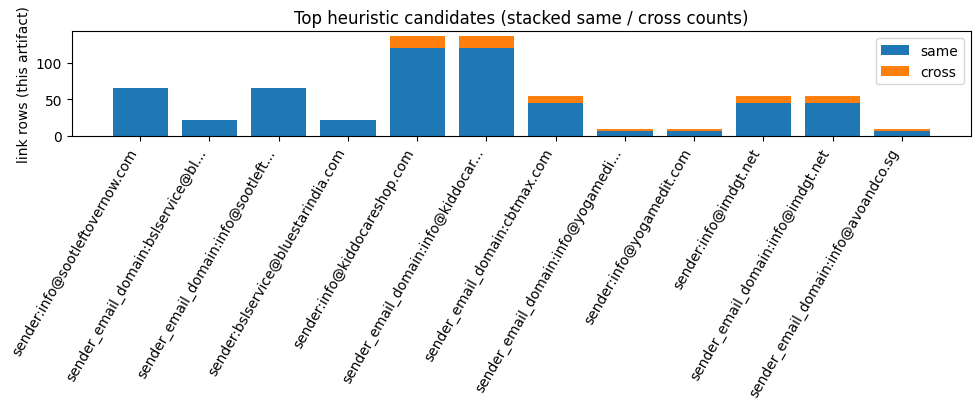

In [33]:
artifact_candidates = artifact_filtering_candidates(artifact_summary_df, min_conf_links=5)
if artifact_candidates.empty:
    display(Markdown("No candidates passed minimum support — skip."))
else:
    _show = artifact_candidates[
        [
            c
            for c in (
                "artifact_type",
                "artifact_value",
                "n_cross",
                "n_same",
                "frac_cross_among_confident",
                "n_shards_containing",
                "high_shard_freq_heuristic",
            )
            if c in artifact_candidates.columns
        ]
    ].head(18)
    with pd.option_context("display.max_colwidth", 80):
        display(_show)
    _top = artifact_candidates.head(12).copy()
    _top["plot_label"] = _top.apply(
        lambda r: plot_label_short(f"{r['artifact_type']}:{r['artifact_value']}", 36),
        axis=1,
    )
    fig, ax = plt.subplots(figsize=(10, 4.2))
    x = np.arange(len(_top))
    ax.bar(x, _top["n_same"], color=COLOR_SAME, label="same")
    ax.bar(x, _top["n_cross"], bottom=_top["n_same"], color=COLOR_CROSS, label="cross")
    ax.set_xticks(x)
    ax.set_xticklabels(_top["plot_label"], rotation=60, ha="right")
    ax.set_ylabel("link rows (this artifact)")
    ax.set_title("Top heuristic candidates (stacked same / cross counts)")
    ax.legend()
    plt.tight_layout()
    plt.show()


# Residual failure analysis: what problem is left for a GNN to solve?

The **Step-2 shard graph baseline** (current weighted edges) is already strong: shards are very pure on GT, so most loss is **completeness / recall**—getting the right campaign pieces connected.

This section estimates **where recall is still lost**:

* Stage-1 **noise / singleton** shards vs **normal** shards  
* **Missing same-campaign links** (never in the candidate table vs **present but filtered** by weight)  
* **Near-miss semantic** pairs if cosine thresholds were relaxed  
* Whether off-component shards could **attach** to the dominant GT-connected component (semantic / direct edges)

**GT is used only for evaluation**, not for training. Outputs are diagnostics to choose among: better shard creation, edge rescoring, missing-edge completion near semantic thresholds, or **node-to-community** attachment.

**How to read outputs:** small summary tables + a few plots with explicit titles/axes; larger tables are written to CSV under `OUT_DIR`.


## Setup (residual section)

Reads `STEP2` graph artifacts from variables defined earlier (`nodes_df`, `edges_df`, `assignments_df`, `shard_summary`, …).

* **`BASELINE_MIN_EDGE_WEIGHT`**: edges with `edge_weight >=` this value are **active** in the connectivity model (default `0.0` = every row in `semantic_shard_step2_edges_weighted.csv` counts).  
* **`OPERATING_MIN_EDGE_WEIGHT`**: stricter cutoff used to classify **existing_edge_below_operating_threshold** in the missing-link breakdown (loaded from `semantic_shard_step2_graph_summary.json` when available, else falls back to the **median** edge weight, or `0` if missing).  
* **Singleton / noise shard**: `size <= 1` in `nodes_df` (Stage-1 shard size).


In [34]:
from analysis.utils.semantic_shard_residual_failure_helpers import (
    active_edge_keys,
    campaign_fracture_summary_stats,
    classify_disconnected_same_campaign_pairs,
    community_attachment_summary,
    compute_campaign_fracture_table,
    cosine_threshold_new_edge_stats,
    edge_weight_retention_table,
    fractured_campaign_noise_summary,
    fractured_campaigns_at_edge_threshold,
    load_centroid_matrix,
    load_step2_config,
    off_main_shards_and_similarity,
    plot_attachment_stacked,
    plot_campaign_component_bar,
    plot_horizontal_category_bars,
    plot_largest_component_hist,
    plot_max_cos_histogram,
)

_step2_cfg = load_step2_config(STEP2_DIR)
_g = (_step2_cfg.get("graph_config_summary") or {}) if isinstance(_step2_cfg, dict) else {}
BASELINE_MIN_EDGE_WEIGHT = float(_g.get("min_edge_weight_active", _g.get("min_edge_weight", 0.0)) or 0.0)
# Stricter "operating" cutoff for diagnostics: summary JSON, else weight median
if edges_df is not None and not edges_df.empty and "edge_weight" in edges_df.columns:
    _med_w = float(edges_df["edge_weight"].astype(float).median())
else:
    _med_w = 0.0
OPERATING_MIN_EDGE_WEIGHT = float(_g.get("operating_min_edge_weight", _med_w))
SEMANTIC_CANDIDATE_MIN_COS = float(_g.get("semantic_min_cos", _g.get("semantic_min_cosine", 0.72)))

centroid_mat, shard_to_idx = load_centroid_matrix(STEP2_DIR, nodes_df)

display(
    Markdown(
        "**Resolved parameters:** "
        f"`BASELINE_MIN_EDGE_WEIGHT={BASELINE_MIN_EDGE_WEIGHT}`, "
        f"`OPERATING_MIN_EDGE_WEIGHT={OPERATING_MIN_EDGE_WEIGHT}`, "
        f"semantic candidate build cos ≈ `{SEMANTIC_CANDIDATE_MIN_COS}`, "
        f"centroids loaded: `{centroid_mat is not None}`"
    )
)


**Resolved parameters:** `BASELINE_MIN_EDGE_WEIGHT=0.0`, `OPERATING_MIN_EDGE_WEIGHT=1.1004769792835467`, semantic candidate build cos ≈ `0.72`, centroids loaded: `True`

## 1. Campaign fracture inventory

**Interpretation:** For each GT campaign, we connect shards using **active** edges (`edge_weight >= BASELINE_MIN_EDGE_WEIGHT`). If more than one connected component appears among that campaign's shards, the campaign is **fractured** in the current graph.

**Plot 1 (left):** how many campaigns have 1, 2, … components (bucketed tail if many).  
**Plot 2:** among fractured campaigns, how large is the **main** component as a fraction of shards (heavy left = one big piece + small tails; flat = severe splits).


,n_gt_campaigns,n_fractured_campaigns,frac_fractured,n_campaigns_with_any_noise_shard,n_fractured_campaigns_with_noise_shard,mean_largest_component_fraction_fractured,median_largest_component_fraction_fractured
0,27,16,0.592593,18,13,0.467889,0.5


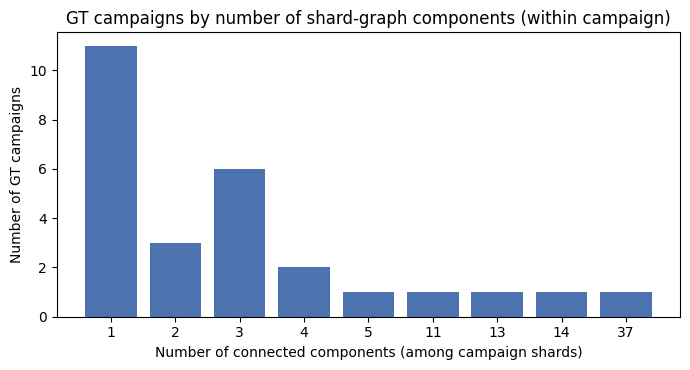

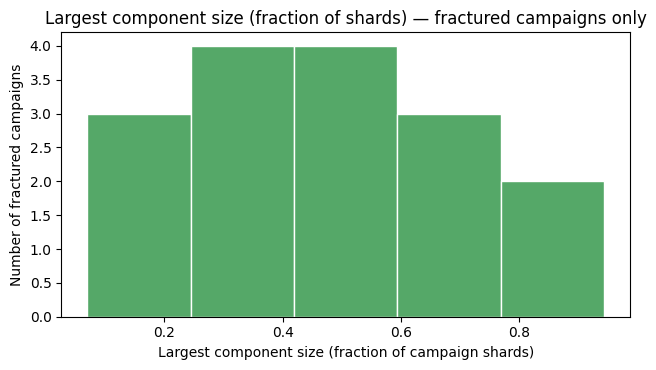

In [35]:
fracture_df = compute_campaign_fracture_table(
    assignments_df,
    gt_label_map,
    edges_df,
    nodes_df,
    min_edge_weight=BASELINE_MIN_EDGE_WEIGHT,
    weight_col="edge_weight",
)
fracture_summary = campaign_fracture_summary_stats(fracture_df)
fracture_df.to_csv(OUT_DIR / "campaign_fracture_detail.csv", index=False)
fracture_summary.to_csv(OUT_DIR / "campaign_fracture_summary.csv", index=False)
display(fracture_summary)

fig = plot_campaign_component_bar(
    fracture_df, title="GT campaigns by number of shard-graph components (within campaign)"
)
fig.savefig(OUT_DIR / "residual_campaign_component_counts.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

frac_only = fracture_df[fracture_df["n_graph_components_in_campaign"] > 1]
if len(frac_only):
    fig2 = plot_largest_component_hist(
        frac_only, title="Largest component size (fraction of shards) — fractured campaigns only"
    )
    fig2.savefig(OUT_DIR / "residual_largest_component_fraction_hist.png", dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig2)
else:
    display(Markdown("_No fractured campaigns at this baseline — histogram skipped._"))


## 2. Noise / singleton contribution (fractured campaigns)

**Interpretation:** Among emails in **fractured** GT campaigns, what fraction sit in **singleton** shards (`size <= 1`)?

**Plots:** (1) two-bar counts normal vs noise shard emails; (2) stacked counts of fractured campaigns by noise involvement.


,n_fractured_campaigns,n_fractured_campaigns_with_noise,frac_fractured_campaigns_with_noise,n_fractured_emails,n_fractured_emails_in_noise,frac_fractured_emails_in_noise
0,16,13,0.8125,347,133,0.383285


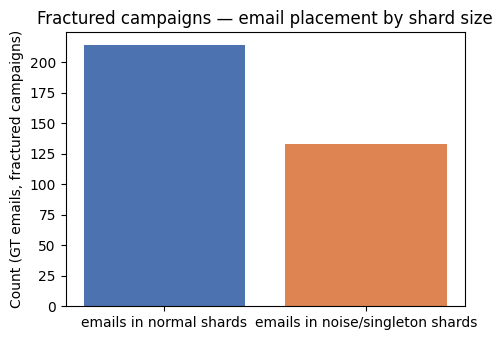

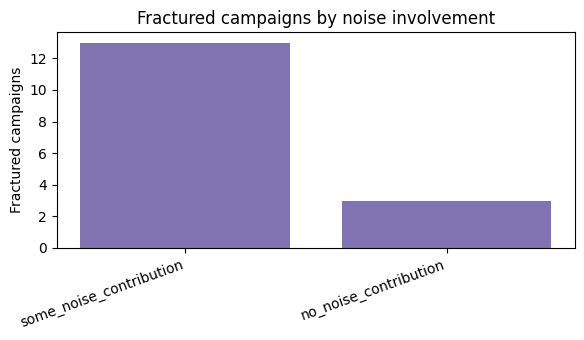

In [36]:
noise_summary, noise_buckets = fractured_campaign_noise_summary(
    assignments_df, gt_label_map, fracture_df, nodes_df
)
noise_summary.to_csv(OUT_DIR / "noise_contribution_summary.csv", index=False)
display(noise_summary)

_gt = {str(k): v for k, v in gt_label_map.items()}
_frid = set(fracture_df.loc[fracture_df["n_graph_components_in_campaign"] > 1, "campaign_id"])
_ad = assignments_df.copy()
_ad["external_id"] = _ad["external_id"].astype(str)
_ad["shard_id"] = _ad["shard_id"].astype(str)
_ad = _ad[_ad["external_id"].isin(_gt)].copy()
_ad["campaign_id"] = _ad["external_id"].map(_gt)
_ad = _ad[_ad["campaign_id"].isin(_frid)].copy()
_sz = _ad["shard_id"].map(lambda s: int(dict(zip(nodes_df["shard_id"].astype(str), nodes_df["size"], strict=False)).get(str(s), 999)))
_ad["is_noise"] = _sz <= 1

fig, ax = plt.subplots(figsize=(5, 3.5))
counts = [int((~_ad["is_noise"]).sum()), int(_ad["is_noise"].sum())]
ax.bar(["emails in normal shards", "emails in noise/singleton shards"], counts, color=["#4c72b0", "#dd8452"])
ax.set_ylabel("Count (GT emails, fractured campaigns)")
ax.set_title("Fractured campaigns — email placement by shard size")
plt.tight_layout()
fig.savefig(OUT_DIR / "residual_noise_email_bars.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

if not noise_buckets.empty:
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(noise_buckets["bucket"], noise_buckets["n_campaigns"], color="#8172b2")
    ax.set_ylabel("Fractured campaigns")
    ax.set_title("Fractured campaigns by noise involvement")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "residual_noise_stacked_groups.png", dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## 3. Missing-link opportunity (same-campaign, different component)

**Interpretation:** Take each **unordered shard pair** that (i) belongs to the same GT campaign and (ii) lies in **different** baseline connected components. Classify:

* **existing_edge_below_operating_threshold** — row exists in `edges_df` but `edge_weight < OPERATING_MIN_EDGE_WEIGHT`  
* **no_edge_but_high_semantic_candidate** — no edge row; centroid cosine ≥ 0.85 (configurable)  
* **no_edge_but_some_direct_infra_support** — no edge row; any parsed infra-set overlap on `nodes_df`  
* **no_edge_no_direct_support** — else  
* **pair_anomaly_high_weight_but_disconnected** — should be rare (edge active in model but still disconnected ⇒ check weights / keys)

Large pair list: `missing_link_opportunity_pairs_detail.csv`.


,category,n_same_campaign_disconnected_pairs,fraction
0,no_edge_but_high_semantic_candidate,1603,0.706167
1,no_edge_no_direct_support,625,0.275330
2,existing_edge_below_operating_threshold,42,0.018502


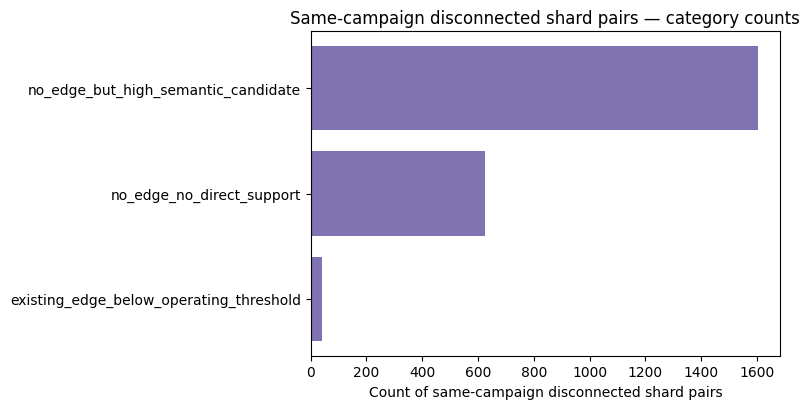

In [37]:
NEAR_MISS_PAIR_COS = 0.85
pair_detail, miss_summary = classify_disconnected_same_campaign_pairs(
    fracture_df,
    assignments_df,
    gt_label_map,
    edges_df,
    nodes_df,
    active_min_edge_weight=OPERATING_MIN_EDGE_WEIGHT,
    near_miss_cos=NEAR_MISS_PAIR_COS,
    weight_col="edge_weight",
    centroid_mat=centroid_mat,
    shard_to_idx=shard_to_idx,
)
miss_summary.to_csv(OUT_DIR / "missing_link_opportunity_breakdown.csv", index=False)
pair_detail.to_csv(OUT_DIR / "missing_link_opportunity_pairs_detail.csv", index=False)
display(miss_summary)

if not miss_summary.empty:
    fig = plot_horizontal_category_bars(
        miss_summary, title="Same-campaign disconnected shard pairs — category counts"
    )
    fig.savefig(OUT_DIR / "residual_missing_link_horizontal.png", dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)
else:
    display(Markdown("_No disconnected same-campaign pairs to classify._"))


## 4. Cosine-threshold sweep (new pairwise opportunities)

**Interpretation:** For cosines τ in `{0.90, 0.85, 0.80}` and the **semantic candidate** floor from Step-2 (`SEMANTIC_CANDIDATE_MIN_COS`), count **new** shard pairs with cosine ≥ τ that are **not** already in the **baseline active** edge set. Bars/lines show how many new edges are GT-same vs cross vs ambiguous.

**Column `n_fractured_campaigns_with_new_same_bridge`:** fractured campaigns where at least one **new same-GT** pair would connect two different baseline components.


[cos-sweep] tau=0.720 candidate_pairs=4189003
[cos-sweep] tau=0.800 candidate_pairs=3283550
[cos-sweep] tau=0.850 candidate_pairs=578524
[cos-sweep] tau=0.900 candidate_pairs=18291


,threshold,n_new_same,n_new_cross,n_new_ambiguous,same_fraction_among_new_confident,cross_fraction_among_new_confident,n_fractured_campaigns_with_new_same_bridge
0,0.72,3592,35658,4145363,0.091516,0.908484,16
1,0.80,3587,30828,3244766,0.104228,0.895772,16
2,0.85,2826,6571,565094,0.300734,0.699266,16
3,0.90,586,116,14753,0.834758,0.165242,12


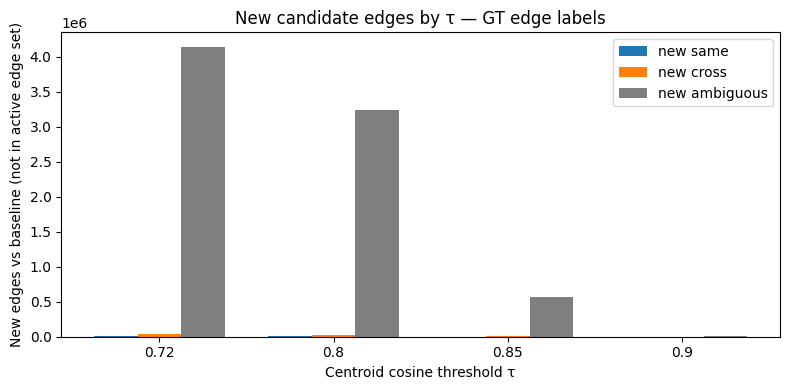

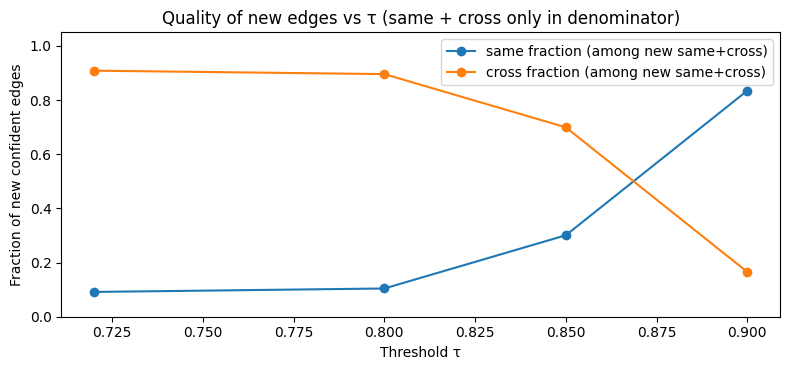

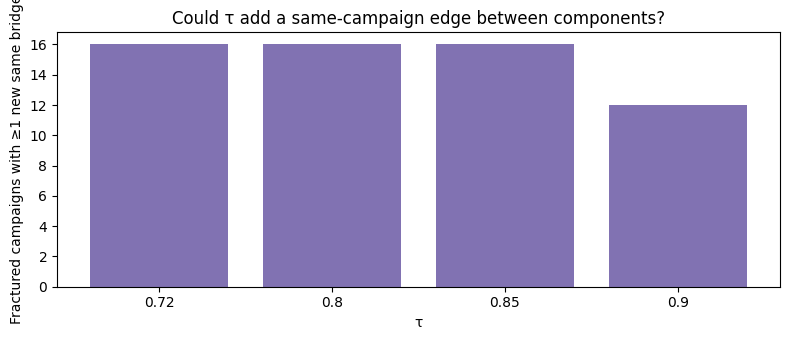

In [38]:
if centroid_mat is None or not len(shard_to_idx):
    display(Markdown("_Skip cosine sweep: centroids not aligned with `nodes_df`._"))
    cos_sweep_df = pd.DataFrame()
else:
    _base_keys = active_edge_keys(
        edges_df, min_edge_weight=BASELINE_MIN_EDGE_WEIGHT, weight_col="edge_weight"
    )
    _taus = sorted(set([0.90, 0.85, 0.80, float(SEMANTIC_CANDIDATE_MIN_COS)]))
    cos_sweep_df = cosine_threshold_new_edge_stats(
        edges_df,
        centroid_mat,
        shard_to_idx,
        shard_summary,
        thresholds=_taus,
        baseline_active_keys=_base_keys,
        fracture_df=fracture_df,
        assignments_df=assignments_df,
        gt_label_map=gt_label_map,
        active_min_edge_weight=BASELINE_MIN_EDGE_WEIGHT,
        weight_col="edge_weight",
    )
    cos_sweep_df.to_csv(OUT_DIR / "cosine_threshold_edge_opportunities.csv", index=False)
    display(cos_sweep_df)

    if not cos_sweep_df.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        x = np.arange(len(cos_sweep_df))
        w = 0.25
        ax.bar(x - w, cos_sweep_df["n_new_same"], width=w, label="new same", color=COLOR_SAME)
        ax.bar(x, cos_sweep_df["n_new_cross"], width=w, label="new cross", color=COLOR_CROSS)
        ax.bar(x + w, cos_sweep_df["n_new_ambiguous"], width=w, label="new ambiguous", color=COLOR_AMBIG)
        ax.set_xticks(x)
        ax.set_xticklabels([str(round(t, 3)) for t in cos_sweep_df["threshold"]])
        ax.set_xlabel("Centroid cosine threshold τ")
        ax.set_ylabel("New edges vs baseline (not in active edge set)")
        ax.set_title("New candidate edges by τ — GT edge labels")
        ax.legend()
        plt.tight_layout()
        fig.savefig(OUT_DIR / "residual_cosine_sweep_grouped.png", dpi=120, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        fig, ax = plt.subplots(figsize=(8, 3.8))
        ax.plot(cos_sweep_df["threshold"], cos_sweep_df["same_fraction_among_new_confident"], marker="o", label="same fraction (among new same+cross)", color=COLOR_SAME)
        ax.plot(cos_sweep_df["threshold"], cos_sweep_df["cross_fraction_among_new_confident"], marker="o", label="cross fraction (among new same+cross)", color=COLOR_CROSS)
        ax.set_xlabel("Threshold τ")
        ax.set_ylabel("Fraction of new confident edges")
        ax.set_ylim(0, 1.05)
        ax.legend()
        ax.set_title("Quality of new edges vs τ (same + cross only in denominator)")
        plt.tight_layout()
        fig.savefig(OUT_DIR / "residual_cosine_sweep_lines.png", dpi=120, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        fig, ax = plt.subplots(figsize=(8, 3.5))
        ax.bar(
            [str(round(t, 3)) for t in cos_sweep_df["threshold"]],
            cos_sweep_df["n_fractured_campaigns_with_new_same_bridge"],
            color="#8172b2",
        )
        ax.set_xlabel("τ")
        ax.set_ylabel("Fractured campaigns with ≥1 new same bridge")
        ax.set_title("Could τ add a same-campaign edge between components?")
        plt.tight_layout()
        fig.savefig(OUT_DIR / "residual_cosine_sweep_reconnect.png", dpi=120, bbox_inches="tight")
        plt.show()
        plt.close(fig)


## 5. Edge-weight threshold sweep

**Interpretation:** Retention / removal of labeled **same** vs **cross** edges as we require higher `edge_weight`. Shows whether true same-campaign links are concentrated at **low weights** (sensitive to stricter thresholds).

Fractured-campaign count vs threshold is saved in the same CSV as auxiliary columns if computed.


,threshold,frac_same_retained,frac_cross_retained,frac_same_removed,frac_cross_removed,n_fractured_campaigns
0,0.000000,1.000000,1.00,0.000000,0.00,16
1,0.527509,1.000000,1.00,0.000000,0.00,16
2,0.548597,0.948590,1.00,0.051410,0.00,17
3,1.100477,0.752902,0.42,0.247098,0.58,20
4,1.125848,0.139303,0.02,0.860697,0.98,22
5,1.359701,0.029851,0.02,0.970149,0.98,25
6,2.325321,0.000000,0.00,1.000000,1.00,26


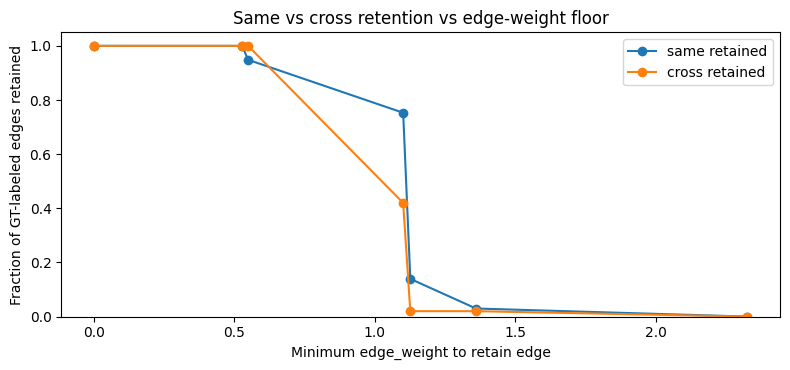

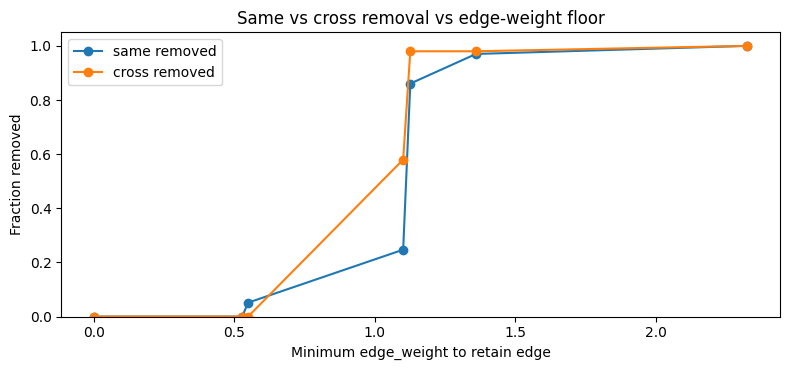

In [39]:
if edges_df.empty or "edge_weight" not in edges_df.columns:
    display(Markdown("_Skip edge-weight sweep: no edge weights._"))
    sweep_df = pd.DataFrame()
else:
    ew = edges_df["edge_weight"].astype(float)
    sweep_thr = sorted(set(
        [float(ew.quantile(q)) for q in (0.0, 0.25, 0.5, 0.75, 0.9)]
        + [float(ew.min()), float(ew.max()), OPERATING_MIN_EDGE_WEIGHT, BASELINE_MIN_EDGE_WEIGHT]
    ))
    sweep_df = edge_weight_retention_table(
        edges_df, shard_summary, thresholds=sweep_thr, weight_col="edge_weight"
    )
    fc_extra = fractured_campaigns_at_edge_threshold(
        fracture_df,
        assignments_df,
        gt_label_map,
        edges_df,
        thresholds=sweep_thr,
        weight_col="edge_weight",
    )
    sweep_df = sweep_df.merge(fc_extra, on="threshold", how="left")
    sweep_df.to_csv(OUT_DIR / "edge_weight_threshold_retention.csv", index=False)
    _swc = [c for c in ["threshold", "frac_same_retained", "frac_cross_retained", "frac_same_removed", "frac_cross_removed", "n_fractured_campaigns"] if c in sweep_df.columns]
    display(sweep_df[_swc])

    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.plot(sweep_df["threshold"], sweep_df["frac_same_retained"], marker="o", label="same retained", color=COLOR_SAME)
    ax.plot(sweep_df["threshold"], sweep_df["frac_cross_retained"], marker="o", label="cross retained", color=COLOR_CROSS)
    ax.set_xlabel("Minimum edge_weight to retain edge")
    ax.set_ylabel("Fraction of GT-labeled edges retained")
    ax.set_title("Same vs cross retention vs edge-weight floor")
    ax.legend()
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    fig.savefig(OUT_DIR / "residual_edge_weight_retention.png", dpi=168, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.plot(sweep_df["threshold"], sweep_df["frac_same_removed"], marker="o", label="same removed", color=COLOR_SAME)
    ax.plot(sweep_df["threshold"], sweep_df["frac_cross_removed"], marker="o", label="cross removed", color=COLOR_CROSS)
    ax.set_xlabel("Minimum edge_weight to retain edge")
    ax.set_ylabel("Fraction removed")
    ax.set_title("Same vs cross removal vs edge-weight floor")
    ax.legend()
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    fig.savefig(OUT_DIR / "residual_edge_weight_removal.png", dpi=168, bbox_inches="tight")
    plt.show()
    plt.close(fig)


## 6. Community attachment (off–largest-component shards)

**Interpretation:** For shards in **fractured** campaigns that are **not** in the largest connected component, measure **max centroid cosine** to shards in that largest component and whether any **active** edge touches the target component.

**Noise vs normal** uses `size <= 1`. Off-main shard detail is in `community_attachment_off_main_detail.csv`.


,group,n_shards,frac_sem_match_ge_0.90,frac_sem_match_ge_0.85,frac_with_any_direct_support,frac_with_multi_edge_to_target
0,noise_or_singleton,56,0.535714,0.750000,0.0,0.0
1,normal_shard_off_component,53,0.207547,0.660377,0.0,0.0


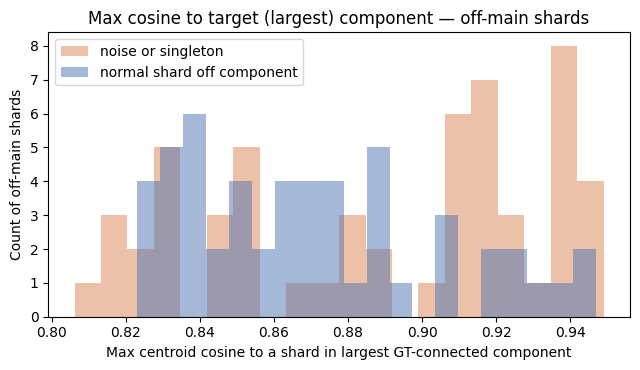

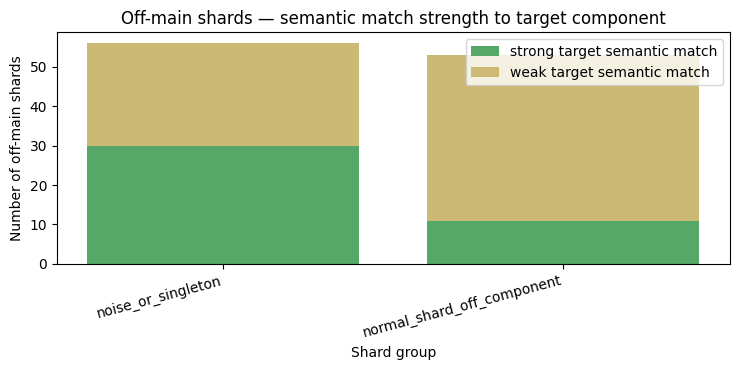

In [40]:
off_main = off_main_shards_and_similarity(
    fracture_df,
    assignments_df,
    gt_label_map,
    edges_df,
    nodes_df,
    active_min_edge_weight=BASELINE_MIN_EDGE_WEIGHT,
    weight_col="edge_weight",
    centroid_mat=centroid_mat,
    shard_to_idx=shard_to_idx,
)
attach_summary = community_attachment_summary(off_main)
off_main.to_csv(OUT_DIR / "community_attachment_off_main_detail.csv", index=False)
attach_summary.to_csv(OUT_DIR / "community_attachment_summary.csv", index=False)
display(attach_summary)

if not off_main.empty and centroid_mat is not None:
    fig = plot_max_cos_histogram(
        off_main, title="Max cosine to target (largest) component — off-main shards"
    )
    fig.savefig(OUT_DIR / "residual_attachment_max_cos_hist.png", dpi=168, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    fig2 = plot_attachment_stacked(
        off_main, title="Off-main shards — semantic match strength to target component"
    )
    fig2.savefig(OUT_DIR / "residual_attachment_stacked.png", dpi=168, bbox_inches="tight")
    plt.show()
    plt.close(fig2)
else:
    display(Markdown("_Skip attachment plots (no off-main rows or no centroids)._"))


## 7. Decision summary (fill using numbers above)

1. **How much of remaining failure is due to noise/singleton shards?**  
   → See `noise_contribution_summary.csv` and §2 plots (`frac_fractured_emails_in_noise`).

2. **How much is due to missing same-campaign edges among normal shards?**  
   → §3 category counts (especially `no_edge_*` vs `existing_edge_below_operating_threshold`) and `missing_link_opportunity_breakdown.csv`.

3. **Do lower semantic thresholds add useful same edges or mostly cross bridges?**  
   → §4 `cosine_threshold_edge_opportunities.csv` — compare `n_new_same` vs `n_new_cross` and the line plot fractions.

4. **Are misses better explained by pairwise completion or community attachment?**  
   → §6 `community_attachment_summary.csv` — `frac_sem_match_ge_0.90` / `frac_with_any_direct_support` split by `group`.

5. **Most plausible next direction (pick one or combine):**  
   * Better Stage-1 / noise handling  
   * **Edge rescoring** or conditional validation of low-weight same signals  
   * **Missing-edge completion** near semantic τ  
   * **Node-to-community** attachment when off-main shards show high cosine to the dominant component  
   * **Limited headroom** if most failures are `no_edge_no_direct_support` and attachment cosines are low  

_Edit this cell after a run with one-sentence verdicts if helpful._


## One-cell manual review export

Run **only the next cell** to generate `manual_review_browser.html` (alignment + pair selection + HTML export in one pass).


In [ ]:
# ONE-CELL manual review browser export (run this cell only)
from __future__ import annotations

import ast
import html
import json
from pathlib import Path

import numpy as np
import pandas as pd

# Self-contained bootstrap: works even from a fresh kernel.
if "PROJECT_ROOT" not in globals():
    _here = Path.cwd().resolve()
    PROJECT_ROOT = _here if (_here / "pipeline_config.json").is_file() else _here.parent
if "OUT_DIR" not in globals():
    OUT_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_oracle_headroom"
    OUT_DIR.mkdir(parents=True, exist_ok=True)
if "STEP2_DIR" not in globals():
    STEP2_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step2_graph_routing"

if any(k not in globals() for k in ["assignments_df", "nodes_df", "edges_df", "gt_label_map"]):
    from analysis.utils.raw_gnn_notebook import load_ground_truth_structures
    from analysis.utils.semantic_shard_oracle_headroom_helpers import (
        load_step1_assignments,
        build_shard_gt_summary,
        label_candidate_edges_taxonomy,
        build_edge_analysis_dataframe,
    )
    from analysis.utils.semantic_shard_step3_helpers import load_step2_artifacts

    STEP1_ASSIGNMENTS = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_step1" / "semantic_shard_step1_assignments.csv"
    GT_JSON = PROJECT_ROOT / "data" / "groundtruth" / "ground_truth.json"

    gt_label_map, _eid_row, _campaign_to_members = load_ground_truth_structures(GT_JSON)
    assignments_df = load_step1_assignments(STEP1_ASSIGNMENTS)
    nodes_df, edges_df, _candidates_df = load_step2_artifacts(STEP2_DIR)

if "edge_analysis_df" not in globals() or edge_analysis_df is None or len(edge_analysis_df) == 0:
    from analysis.utils.semantic_shard_oracle_headroom_helpers import (
        build_shard_gt_summary,
        label_candidate_edges_taxonomy,
        build_edge_analysis_dataframe,
    )

    shard_summary = build_shard_gt_summary(assignments_df, gt_label_map, min_labeled_for_stats=1)
    edges_tax = label_candidate_edges_taxonomy(
        edges_df,
        shard_summary,
        min_labeled_per_endpoint=1,
        min_dominant_fraction=0.7,
    )
    edge_analysis_df = build_edge_analysis_dataframe(edges_df, edges_tax)

TOP_N = 60
TOP_N_NOISE = 30
MIN_BODY_COSINE = 0.85
MIN_SEMANTIC_EDGE = 0.85
SUBJECT_CHARS = 220
BODY_CHARS = 1400
LIST_N = 8
OUT_HTML = OUT_DIR / "manual_review_browser.html"


def _s(x):
    if x is None:
        return ""
    if isinstance(x, float) and pd.isna(x):
        return ""
    return str(x)


def _norm(x):
    return " ".join(_s(x).split())


def _snip(x, n):
    t = _norm(x)
    if not t:
        return "(unavailable)"
    return t if len(t) <= n else t[:n] + " ..."


def _parse_set_cell(raw):
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return set()
    s = str(raw).strip()
    if not s or s.lower() in {"nan", "none", "[]"}:
        return set()
    try:
        v = ast.literal_eval(s)
        if isinstance(v, (list, tuple, set)):
            return {str(x).strip() for x in v if str(x).strip()}
    except Exception:
        pass
    try:
        v = json.loads(s)
        if isinstance(v, list):
            return {str(x).strip() for x in v if str(x).strip()}
    except Exception:
        pass
    return set()


def _fmt_vals(vals, k=LIST_N):
    xs = [str(v).strip() for v in vals if str(v).strip()]
    return sorted(dict.fromkeys(xs))[:k]


def _overlap(a, b, k=LIST_N):
    sa = {str(x).strip() for x in a if str(x).strip()}
    sb = {str(x).strip() for x in b if str(x).strip()}
    return sorted(sa & sb)[:k]


# 1) Build shard member index
member_idx = {}
if "member_external_ids" in nodes_df.columns:
    for _, r in nodes_df[["shard_id", "member_external_ids"]].iterrows():
        sid = str(r["shard_id"])
        raw = r["member_external_ids"]
        vals = []
        try:
            v = ast.literal_eval(str(raw))
            if isinstance(v, (list, tuple, set)):
                vals = [str(x).strip() for x in v if str(x).strip()]
        except Exception:
            pass
        member_idx[sid] = vals

# 2) Parse dataset emails and ALIGN with shard external_ids via graph meta
# Keep this notebook-cell self-contained: avoid importing core.graph.common.
from urllib.parse import urlparse

def _extract_email_domain_local(addr: str) -> str:
    s = _s(addr).strip().lower()
    if "@" not in s:
        return ""
    return s.rsplit("@", 1)[-1].strip()

def _parse_url_components_local(u: str) -> dict:
    s = _s(u).strip()
    if not s:
        return {"domain": "", "stem": ""}
    try:
        purl = urlparse(s)
        return {
            "domain": (_s(purl.hostname).strip().lower() if purl.hostname else ""),
            "stem": (_s(purl.path).strip() if purl.path else ""),
        }
    except Exception:
        return {"domain": "", "stem": ""}

def _extract_misp_events(raw_obj):
    if isinstance(raw_obj, list):
        return raw_obj
    if isinstance(raw_obj, dict) and isinstance(raw_obj.get("response"), list):
        return raw_obj["response"]
    if isinstance(raw_obj, dict) and isinstance(raw_obj.get("events"), list):
        return raw_obj["events"]
    return []

def _parse_misp_events_light(misp_events: list[dict]) -> list[dict]:
    out = []
    for idx_ev, ev in enumerate(misp_events):
        event = ev.get("Event", {}) if isinstance(ev, dict) else {}
        attrs = event.get("Attribute", []) or []
        rec = {
            "external_id": _s(event.get("external_id", "")).strip() or str(event.get("email_index", idx_ev)),
            "email_index": event.get("email_index", idx_ev),
            "subject": "",
            "body": "",
            "senders": [],
            "urls": [],
            "attachments": [],
            "received_hops": [],
            "return_path": {},
            "html": {},
            "date": "",
        }
        for a in attrs:
            if not isinstance(a, dict):
                continue
            t = _s(a.get("type", "")).strip().lower()
            v = a.get("value", "")
            if t in {"email-subject", "subject"}:
                rec["subject"] = _s(v)
            elif t in {"email-body", "body"}:
                rec["body"] = _s(v)
            elif t in {"email-src", "from"}:
                vals = v if isinstance(v, list) else [v]
                rec["senders"].extend([_s(x).strip().lower() for x in vals if _s(x).strip()])
            elif t == "header_return-path":
                if isinstance(v, dict):
                    rec["return_path"] = v
            elif t == "header_received":
                if isinstance(v, list):
                    rec["received_hops"] = [x for x in v if isinstance(x, dict)]
            elif t == "html":
                if isinstance(v, dict):
                    rec["html"] = v
            elif t in {"date", "email-date"}:
                rec["date"] = _s(v).strip()
            elif t == "url":
                vals = v if isinstance(v, list) else [v]
                rec["urls"].extend([_s(x).strip() for x in vals if _s(x).strip()])
            elif "attachment" in t:
                vals = v if isinstance(v, list) else [v]
                rec["attachments"].extend([_s(x).strip().lower() for x in vals if _s(x).strip()])
        out.append(rec)
    return out

misp_path = PROJECT_ROOT / "data" / "misp" / "incidents-lake-misp-large.json"
raw = json.loads(misp_path.read_text(encoding="utf-8"))
misp_events = _extract_misp_events(raw)
parsed = _parse_misp_events_light(misp_events)

meta_ids = []
for p in [
    PROJECT_ROOT / "core" / "graph" / "output" / "incidents-lake-misp-large_hetero.meta.json",
    PROJECT_ROOT / "core" / "graph" / "output" / "incidents-lake-misp-large.meta.json",
]:
    if not p.is_file():
        continue
    try:
        meta = json.loads(p.read_text(encoding="utf-8"))
        from analysis.utils import graph_structure_helpers as gh

        meta_ids = [str(x) for x in gh.email_external_id_list(meta)]
        if meta_ids:
            break
    except Exception:
        continue

email_by_id = {}
for i, em in enumerate(parsed):
    cands = []
    d = _s(em.get("external_id", "")).strip()
    if d:
        cands.append(d)
    ei = em.get("email_index", None)
    try:
        ei = int(ei)
        if 0 <= ei < len(meta_ids):
            cands.append(meta_ids[ei])
    except Exception:
        pass
    if i < len(meta_ids):
        cands.append(meta_ids[i])

    senders = [str(x).strip().lower() for x in (em.get("senders") or []) if str(x).strip()]
    sdom = [_extract_email_domain_local(x) for x in senders if "@" in x]
    rp = em.get("return_path") if isinstance(em.get("return_path"), dict) else {}
    urls = [str(x).strip() for x in (em.get("urls") or []) if str(x).strip()]
    domains, stems = [], []
    for u in urls:
        try:
            c = _parse_url_components_local(u)
            d0 = _s(c.get("domain", "")).strip().lower()
            s0 = _s(c.get("stem", "")).strip()
            if d0:
                domains.append(d0)
            if s0:
                stems.append(s0)
        except Exception:
            pass
    hops = em.get("received_hops") if isinstance(em.get("received_hops"), list) else []
    helo = [_s(h.get("helo_host", "")).strip().lower() for h in hops if isinstance(h, dict) and _s(h.get("helo_host", "")).strip()]
    html_obj = em.get("html") if isinstance(em.get("html"), dict) else {}
    fp = _s(html_obj.get("structure_fingerprint", "")).strip().lower() if html_obj else ""
    atts = [str(x).strip().lower() for x in (em.get("attachments") or []) if str(x).strip()]

    payload = {
        "subject": _s(em.get("subject", "")).strip(),
        "body": _s(em.get("body", "")),
        "date": _s(em.get("date", "")).strip(),
        "senders": _fmt_vals(senders, 20),
        "sender_domains": _fmt_vals(sdom, 20),
        "return_path_email": _s(rp.get("email", "")).strip().lower(),
        "return_path_domain": _s(rp.get("domain", "")).strip().lower(),
        "urls": _fmt_vals(urls, 30),
        "domains": _fmt_vals(domains, 30),
        "stems": _fmt_vals(stems, 30),
        "attachments": _fmt_vals(atts, 30),
        "helo_hosts": _fmt_vals(helo, 20),
        "html_structure_fingerprint": fp,
    }
    for cid in cands:
        if cid:
            email_by_id[str(cid)] = payload

# 3) Build mappings used for pair cards
a = assignments_df.copy()
a["external_id"] = a["external_id"].astype(str)
a["shard_id"] = a["shard_id"].astype(str)
email_to_shard = dict(zip(a["external_id"], a["shard_id"], strict=False))
gt_map = {str(k): v for k, v in gt_label_map.items()}

# Same subject/body vectors as semantic_shard_prototype_step1 (HDBSCAN on L2-normalized concat(subj, body)).
EMBEDDINGS_JSON = PROJECT_ROOT / "core" / "utils" / "embeddings" / "output" / "embeddings.json"
id_to_subj: dict[str, np.ndarray] = {}
id_to_body: dict[str, np.ndarray] = {}
_emb_raw = json.loads(Path(EMBEDDINGS_JSON).read_text(encoding="utf-8"))
_by_key = _emb_raw.get("by_key") or {}
if isinstance(_by_key, dict):
    for _k, _v in _by_key.items():
        if not isinstance(_v, dict):
            continue
        _sj = np.asarray(_v.get("subj") or [], dtype=np.float32).reshape(-1)
        _bd = np.asarray(_v.get("body") or [], dtype=np.float32).reshape(-1)
        _eid = str(_v.get("external_id") or _k)
        if _sj.size:
            id_to_subj[_eid] = _sj
        if _bd.size:
            id_to_body[_eid] = _bd
print(f"Loaded Step-1 embedding cache: subj={len(id_to_subj):,} body={len(id_to_body):,} <- {EMBEDDINGS_JSON.name}")

assign_ids = set(a["external_id"])
overlap_n = len(assign_ids & set(email_by_id.keys()))

edge_key_set = set()
for _, r in edges_df[["shard_a", "shard_b"]].iterrows():
    sa, sb = str(r["shard_a"]), str(r["shard_b"])
    edge_key_set.add((sa, sb) if sa < sb else (sb, sa))


def _connected(sa, sb):
    k = (sa, sb) if sa < sb else (sb, sa)
    return k in edge_key_set


def _email_rec(eid):
    rec = (email_by_id.get(str(eid), {}) or {}).copy()
    rec.setdefault("subject", "")
    rec.setdefault("body", "")
    rec.setdefault("date", "")
    rec.setdefault("senders", [])
    rec.setdefault("sender_domains", [])
    rec.setdefault("return_path_email", "")
    rec.setdefault("return_path_domain", "")
    rec.setdefault("urls", [])
    rec.setdefault("domains", [])
    rec.setdefault("stems", [])
    rec.setdefault("attachments", [])
    rec.setdefault("helo_hosts", [])
    rec.setdefault("html_structure_fingerprint", "")
    rec["external_id"] = str(eid)
    rec["shard_id"] = email_to_shard.get(str(eid), "")
    rec["campaign"] = gt_map.get(str(eid))
    return rec


def _has_text(rec):
    return bool(_norm(rec.get("subject", "")) or _norm(rec.get("body", "")))


def _vec_cos(va: np.ndarray | None, vb: np.ndarray | None) -> float:
    if va is None or vb is None:
        return float("nan")
    va = np.asarray(va, dtype=np.float64).ravel()
    vb = np.asarray(vb, dtype=np.float64).ravel()
    if va.size == 0 or vb.size == 0:
        return float("nan")
    na = float(np.linalg.norm(va))
    nb = float(np.linalg.norm(vb))
    if na == 0.0 or nb == 0.0:
        return float("nan")
    return float(np.dot(va, vb) / (na * nb))


def _best_cross_campaign_embed_pair(sa: str, sb: str):
    """Pick (left, right) with max body embedding cosine among GT-labeled cross-campaign member pairs."""
    ma = member_idx.get(str(sa), [])
    mb = member_idx.get(str(sb), [])
    best_pair = None
    best_bcos = -2.0
    for ea in ma:
        for eb in mb:
            ca = gt_map.get(str(ea))
            cb = gt_map.get(str(eb))
            if ca is None or cb is None:
                continue
            if str(ca) == str(cb):
                continue
            la0 = _email_rec(ea)
            rb0 = _email_rec(eb)
            if not _has_text(la0) or not _has_text(rb0):
                continue
            bcos = _vec_cos(id_to_body.get(str(ea)), id_to_body.get(str(eb)))
            if not np.isfinite(bcos):
                continue
            if bcos > best_bcos:
                best_bcos = bcos
                best_pair = (ea, eb)
    if best_pair is None:
        return None
    ea, eb = best_pair
    scos = _vec_cos(id_to_subj.get(str(ea)), id_to_subj.get(str(eb)))
    return _email_rec(ea), _email_rec(eb), best_bcos, scos


# 4) Construct pair sets from cross-campaign shard edges
score_col = "semantic_aggregate" if "semantic_aggregate" in edge_analysis_df.columns else "centroid_cosine"
cross_edges = edge_analysis_df[edge_analysis_df["link_label"] == "cross"].copy()
cross_edges[score_col] = pd.to_numeric(cross_edges[score_col], errors="coerce")
cross_edges = cross_edges.sort_values(score_col, ascending=False)

pair_rows = []
for _, r in cross_edges.iterrows():
    sa, sb = str(r.get("shard_a", "")), str(r.get("shard_b", ""))
    if not sa or not sb or sa == sb:
        continue
    picked = _best_cross_campaign_embed_pair(sa, sb)
    if picked is None:
        continue
    la, rb, body_cos, subj_cos = picked
    pair_rows.append({
        "shard_a": sa,
        "shard_b": sb,
        "left_external_id": la["external_id"],
        "right_external_id": rb["external_id"],
        "left_campaign": la.get("campaign"),
        "right_campaign": rb.get("campaign"),
        "left_noise": len(member_idx.get(sa, [])) <= 1,
        "right_noise": len(member_idx.get(sb, [])) <= 1,
        "semantic_edge_score": float(r.get(score_col, np.nan)),
        "body_cosine": body_cos,
        "subject_cosine": subj_cos,
    })

pairs_df = pd.DataFrame(pair_rows)
if not pairs_df.empty:
    pairs_df = pairs_df.drop_duplicates(subset=["left_external_id", "right_external_id"])
    # Strictly keep only cross-campaign, high-similarity email pairs.
    pairs_df = pairs_df[
        (pairs_df["left_campaign"].astype(str) != pairs_df["right_campaign"].astype(str))
        & (pd.to_numeric(pairs_df["body_cosine"], errors="coerce") >= float(MIN_BODY_COSINE))
        & (pd.to_numeric(pairs_df["semantic_edge_score"], errors="coerce") >= float(MIN_SEMANTIC_EDGE))
    ].copy()
    pairs_df = pairs_df.sort_values(["body_cosine", "semantic_edge_score"], ascending=[False, False]).head(TOP_N).reset_index(drop=True)
noise_df = pairs_df[(pairs_df.get("left_noise", False)) | (pairs_df.get("right_noise", False))].head(TOP_N_NOISE).copy() if not pairs_df.empty else pd.DataFrame()

# 5) Render HTML

def _esc(x):
    return html.escape(_s(x))


def _infra_lines(rec):
    fields = [
        ("sender", ", ".join(_fmt_vals(rec.get("senders", [])))),
        ("sender domain", ", ".join(_fmt_vals(rec.get("sender_domains", [])))),
        ("return-path email", rec.get("return_path_email", "")),
        ("return-path domain", rec.get("return_path_domain", "")),
        ("urls", ", ".join(_fmt_vals(rec.get("urls", [])))),
        ("domains", ", ".join(_fmt_vals(rec.get("domains", [])))),
        ("stems", ", ".join(_fmt_vals(rec.get("stems", [])))),
        ("attachments", ", ".join(_fmt_vals(rec.get("attachments", [])))),
        ("helo host", ", ".join(_fmt_vals(rec.get("helo_hosts", [])))),
        ("html fp", rec.get("html_structure_fingerprint", "")),
    ]
    return "".join(f"<div><b>{_esc(k)}:</b> {_esc(v) if _s(v) else '-'}</div>" for k, v in fields)


def _overlap_block(a_rec, b_rec):
    sdom = bool(_overlap(a_rec.get("sender_domains", []), b_rec.get("sender_domains", []), 50))
    rpd = bool(a_rec.get("return_path_domain") and a_rec.get("return_path_domain") == b_rec.get("return_path_domain"))
    hfp = bool(a_rec.get("html_structure_fingerprint") and a_rec.get("html_structure_fingerprint") == b_rec.get("html_structure_fingerprint"))
    return "".join([
        f"<div><b>same sender domain:</b> {'yes' if sdom else 'no'}</div>",
        f"<div><b>same return-path domain:</b> {'yes' if rpd else 'no'}</div>",
        f"<div><b>shared domains:</b> {_esc(', '.join(_overlap(a_rec.get('domains', []), b_rec.get('domains', []))) or '-')}</div>",
        f"<div><b>shared URLs:</b> {_esc(', '.join(_overlap(a_rec.get('urls', []), b_rec.get('urls', []))) or '-')}</div>",
        f"<div><b>shared stems:</b> {_esc(', '.join(_overlap(a_rec.get('stems', []), b_rec.get('stems', []))) or '-')}</div>",
        f"<div><b>shared helo host:</b> {_esc(', '.join(_overlap(a_rec.get('helo_hosts', []), b_rec.get('helo_hosts', []))) or '-')}</div>",
        f"<div><b>shared html fingerprint:</b> {'yes' if hfp else 'no'} {_esc(a_rec.get('html_structure_fingerprint') if hfp else '')}</div>",
        f"<div><b>shared attachment hash:</b> {_esc(', '.join(_overlap(a_rec.get('attachments', []), b_rec.get('attachments', []))) or '-')}</div>",
    ])


def _campaign_for_merge_json(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return None
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, float):
        if x.is_integer():
            return int(x)
        return float(x)
    return str(x)


def _merge_btn_payload_attr(row, section_name: str, rank: int) -> str:
    d = {
        "left_campaign": _campaign_for_merge_json(row.get("left_campaign")),
        "right_campaign": _campaign_for_merge_json(row.get("right_campaign")),
        "left_external_id": str(row.get("left_external_id", "")),
        "right_external_id": str(row.get("right_external_id", "")),
        "shard_a": str(row.get("shard_a", "")),
        "shard_b": str(row.get("shard_b", "")),
        "section": section_name,
        "rank": int(rank),
    }
    raw = json.dumps(d, ensure_ascii=False, separators=(",", ":"))
    s = html.escape(raw, quote=False)
    return s.replace("'", "&#39;")


def _render_card(row, rank, section_name):
    la = _email_rec(row["left_external_id"])
    rb = _email_rec(row["right_external_id"])
    mp = _merge_btn_payload_attr(row, section_name, rank)
    head = f"""
    <div class='pairHeader'>
      <div><b>#{rank}</b> | <b>{_esc(section_name)}</b> | cross-campaign</div>
      <div class='pairMergeRow'>
        <button type='button' class='mergeCampaignsBtn' data-merge-payload='{mp}'>Merge these two campaigns</button>
        <span class='mergePairFeedback' aria-live='polite'></span>
      </div>
      <div>semantic(edge): <b>{float(row.get('semantic_edge_score', np.nan)):.4f}</b> | body emb cos: <b>{float(row.get('body_cosine', np.nan)):.4f}</b> | subject emb cos: <b>{float(row.get('subject_cosine', np.nan)):.4f}</b></div>
      <div>campaigns: <code>{_esc(row.get('left_campaign'))}</code> vs <code>{_esc(row.get('right_campaign'))}</code> | shards: <code>{_esc(row.get('shard_a'))}</code> vs <code>{_esc(row.get('shard_b'))}</code></div>
      <div>connected in graph: <b>{'yes' if _connected(row.get('shard_a'), row.get('shard_b')) else 'no'}</b> | noise side present: <b>{'yes' if bool(row.get('left_noise') or row.get('right_noise')) else 'no'}</b></div>
    </div>
    """
    left = f"""
    <div class='emailCol'>
      <div class='idLine'><code>{_esc(la.get('external_id'))}</code> | shard <code>{_esc(la.get('shard_id'))}</code> | campaign <code>{_esc(la.get('campaign'))}</code></div>
      <div class='subjectLine'>{_esc(_snip(la.get('subject', ''), SUBJECT_CHARS))}</div>
      <div class='metaLine'>date: {_esc(la.get('date', '') or '-')}</div>
      <div class='bodyBox'>{_esc(_snip(la.get('body', ''), BODY_CHARS))}</div>
      <div class='infraBox'>{_infra_lines(la)}</div>
    </div>
    """
    right = f"""
    <div class='emailCol'>
      <div class='idLine'><code>{_esc(rb.get('external_id'))}</code> | shard <code>{_esc(rb.get('shard_id'))}</code> | campaign <code>{_esc(rb.get('campaign'))}</code></div>
      <div class='subjectLine'>{_esc(_snip(rb.get('subject', ''), SUBJECT_CHARS))}</div>
      <div class='metaLine'>date: {_esc(rb.get('date', '') or '-')}</div>
      <div class='bodyBox'>{_esc(_snip(rb.get('body', ''), BODY_CHARS))}</div>
      <div class='infraBox'>{_infra_lines(rb)}</div>
    </div>
    """
    return f"<article class='pairCard'>{head}<div class='overlapBox'>{_overlap_block(la, rb)}</div><div class='pairGrid'>{left}{right}</div></article>"



def _section_html(df, sid, title):
    if df is None or df.empty:
        return ""
    cards = [_render_card(r, i + 1, sid) for i, (_, r) in enumerate(df.iterrows())]
    return f"<section id='{sid}'><h2>{_esc(title)}</h2>{''.join(cards)}</section>"

nav = []
sections = []
if not pairs_df.empty:
    nav.append(f"<li><a href='#crossPairs'>Cross-campaign email pairs (different shards)</a> ({len(pairs_df)})</li>")
    sections.append(_section_html(pairs_df, "crossPairs", "High-priority cross-campaign email pairs (different shards)"))
if not noise_df.empty:
    nav.append(f"<li><a href='#noisePairs'>Noise-involved cross-campaign email pairs</a> ({len(noise_df)})</li>")
    sections.append(_section_html(noise_df, "noisePairs", "Noise-involved cross-campaign email pairs"))

_MERGE_UX_SCRIPT = '\n<script>\n(function () {\n  const STORAGE = "semantic_shard_manual_campaign_merges_v1";\n\n  function defaultDoc() {\n    return { version: 1, merge_edges: [] };\n  }\n\n  function loadDoc() {\n    try {\n      const t = localStorage.getItem(STORAGE);\n      if (!t) return defaultDoc();\n      const j = JSON.parse(t);\n      if (!j || !Array.isArray(j.merge_edges)) return defaultDoc();\n      return j;\n    } catch (e) {\n      return defaultDoc();\n    }\n  }\n\n  function saveDoc(doc) {\n    localStorage.setItem(STORAGE, JSON.stringify(doc));\n    updateToolbar(doc);\n  }\n\n  function edgeKey(l, r) {\n    const x = [String(l), String(r)].sort();\n    return x[0] + "|||" + x[1];\n  }\n\n  function hasEdge(doc, l, r) {\n    const k = edgeKey(l, r);\n    return doc.merge_edges.some(function (e) {\n      return edgeKey(e.left_campaign, e.right_campaign) === k;\n    });\n  }\n\n  function addEdge(rec) {\n    if (rec.left_campaign === undefined || rec.left_campaign === null) return "missing";\n    if (rec.right_campaign === undefined || rec.right_campaign === null) return "missing";\n    if (String(rec.left_campaign) === String(rec.right_campaign)) return "same";\n\n    const doc = loadDoc();\n    if (hasEdge(doc, rec.left_campaign, rec.right_campaign)) return "dup";\n\n    rec.recorded_at = new Date().toISOString();\n    doc.merge_edges.push(rec);\n    saveDoc(doc);\n    return "ok";\n  }\n\n  function undoLast() {\n    const doc = loadDoc();\n    if (!doc.merge_edges.length) return false;\n    doc.merge_edges.pop();\n    saveDoc(doc);\n    return true;\n  }\n\n  function clearAll() {\n    saveDoc(defaultDoc());\n  }\n\n  function flash(msg) {\n    const el = document.getElementById("mergeFlash");\n    if (el) el.textContent = msg || "";\n  }\n\n  function updateToolbar(doc) {\n    const n = document.getElementById("mergeCount");\n    if (n) n.textContent = doc.merge_edges.length + " merge edge(s) stored in this browser";\n  }\n\n  function exportJson() {\n    const doc = loadDoc();\n    const blob = new Blob([JSON.stringify(doc, null, 2)], { type: "application/json" });\n    const a = document.createElement("a");\n    a.href = URL.createObjectURL(blob);\n    a.download = "manual_campaign_merges.json";\n    document.body.appendChild(a);\n    a.click();\n    setTimeout(function () {\n      URL.revokeObjectURL(a.href);\n      a.remove();\n    }, 500);\n    flash("Downloaded manual_campaign_merges.json");\n  }\n\n  function copyJson() {\n    const txt = JSON.stringify(loadDoc(), null, 2);\n    if (navigator.clipboard && navigator.clipboard.writeText) {\n      navigator.clipboard.writeText(txt).then(function () {\n        flash("Copied merge JSON to clipboard.");\n      }).catch(function () {\n        flash("Copy failed — use Export.");\n      });\n    } else {\n      flash("Clipboard API unavailable — use Export.");\n    }\n  }\n\n  document.addEventListener("DOMContentLoaded", function () {\n    updateToolbar(loadDoc());\n\n    document.body.addEventListener("click", function (ev) {\n      const btn = ev.target.closest(".mergeCampaignsBtn");\n      if (!btn) return;\n      const raw = btn.getAttribute("data-merge-payload");\n      if (!raw) return;\n      let rec;\n      try {\n        rec = JSON.parse(raw);\n      } catch (e) {\n        flash("Could not read merge payload.");\n        return;\n      }\n      const card = btn.closest(".pairCard");\n      const fb = btn.parentElement && btn.parentElement.querySelector(".mergePairFeedback");\n      const st = addEdge(rec);\n      if (st === "ok") {\n        if (fb) fb.textContent = "Recorded merge.";\n        if (card) card.classList.add("mergedMarked");\n        flash("Recorded campaign merge.");\n      } else if (st === "dup") {\n        if (fb) fb.textContent = "Already in merge list.";\n        flash("That pair of campaigns is already recorded.");\n      } else if (st === "same") {\n        if (fb) fb.textContent = "Same campaign — skipped.";\n      } else if (st === "missing") {\n        if (fb) fb.textContent = "Missing campaign id — skipped.";\n      }\n    });\n\n    const bE = document.getElementById("btnExportMerges");\n    if (bE) bE.addEventListener("click", exportJson);\n    const bU = document.getElementById("btnUndoMerge");\n    if (bU) bU.addEventListener("click", function () {\n      if (undoLast()) flash("Removed last merge edge."); else flash("Nothing to undo.");\n      updateToolbar(loadDoc());\n    });\n    const bC = document.getElementById("btnClearMerges");\n    if (bC) bC.addEventListener("click", function () {\n      clearAll();\n      document.querySelectorAll(".pairCard.mergedMarked").forEach(function (n) {\n        n.classList.remove("mergedMarked");\n      });\n      document.querySelectorAll(".mergePairFeedback").forEach(function (n) {\n        n.textContent = "";\n      });\n      flash("Cleared all stored merges for this browser.");\n      updateToolbar(loadDoc());\n    });\n    const bCp = document.getElementById("btnCopyMerges");\n    if (bCp) bCp.addEventListener("click", copyJson);\n  });\n})();\n</script>\n'

html_doc_base = f"""
<!DOCTYPE html>
<html lang='en'>
<head>
<meta charset='utf-8' />
<title>Manual Review Browser (One-Cell Export)</title>
<style>
body {{ background:#fff; color:#111; font-family: Arial, sans-serif; margin:20px; }}
h1 {{ margin-bottom:6px; }}
.sub {{ color:#333; margin-bottom:12px; }}
.topNav {{ border:1px solid #ddd; background:#f8f8f8; padding:10px 14px; margin-bottom:16px; }}
.topNav ul {{ margin:0; padding-left:18px; }}
section {{ margin:26px 0 36px; }}
section h2 {{ margin:0 0 10px; padding-bottom:6px; border-bottom:2px solid #ddd; }}
.pairCard {{ border-top:3px solid #cfcfcf; padding:14px 0 18px; margin-bottom:10px; }}
.pairHeader {{ border:1px solid #d7d7d7; background:#fff; padding:10px 12px; margin-bottom:8px; line-height:1.4; }}
.overlapBox {{ border-left:4px solid #4c78a8; background:#f7fbff; padding:8px 10px; margin-bottom:10px; line-height:1.4; }}
.pairGrid {{ display:grid; grid-template-columns: minmax(0,1fr) minmax(0,1fr); gap:14px; align-items:start; }}
.emailCol {{ border:1px solid #e2e2e2; padding:10px; background:#fff; min-height:320px; overflow-wrap:anywhere; }}
.idLine {{ font-size:0.92rem; margin-bottom:6px; overflow-wrap:anywhere; }}
.idLine code {{ word-break: break-all; }}
.subjectLine {{ font-size:1.08rem; font-weight:700; margin:4px 0 6px; }}
.metaLine {{ color:#555; font-size:0.9rem; margin-bottom:6px; }}
.bodyBox {{ white-space:pre-wrap; border:1px solid #efefef; background:#fbfbfb; padding:10px; line-height:1.38; margin-bottom:8px; max-height:360px; overflow:auto; }}
.infraBox {{ font-size:0.9rem; line-height:1.35; overflow-wrap:anywhere; }}
.mergeToolbar {{ border:2px solid #2a6f3b; background:#f4fff6; padding:10px 14px; margin:0 0 18px; line-height:1.45; }}
.mergeToolbar .row2 {{ margin-top:8px; display:flex; flex-wrap:wrap; gap:8px; align-items:center; }}
.mergeToolbar button {{ padding:6px 10px; cursor:pointer; font-size:0.92rem; }}
.mergeFlash {{ margin-top:8px; font-size:0.92rem; color:#222; min-height:1.2em; }}
.pairMergeRow {{ margin-top:8px; display:flex; flex-wrap:wrap; gap:10px; align-items:center; }}
.mergeCampaignsBtn {{ padding:6px 10px; cursor:pointer; font-size:0.9rem; background:#e8f5e9; border:1px solid #2a6f3b; border-radius:4px; }}
.mergeCampaignsBtn:hover {{ background:#d4eed8; }}
.mergePairFeedback {{ font-size:0.88rem; color:#444; }}
.pairCard.mergedMarked {{ border-top-color:#2a6f3b; }}
code {{ font-family: Consolas, monospace; }}
</style>
</head>
<body>
<div id='mergeToolbar' class='mergeToolbar'>
  <div><b>Campaign merges</b> (stored in this browser only; use Export for <code>manual_campaign_merges.json</code>)</div>
  <div class='row2'>
    <span id='mergeCount'>0 merge edge(s) stored</span>
    <button type='button' id='btnExportMerges'>Export merges JSON</button>
    <button type='button' id='btnUndoMerge'>Undo last</button>
    <button type='button' id='btnClearMerges'>Clear all</button>
    <button type='button' id='btnCopyMerges'>Copy JSON</button>
  </div>
  <div id='mergeFlash' class='mergeFlash'></div>
  <div style='font-size:0.88rem;color:#444;margin-top:6px;'>Each click records one <i>undirected</i> merge between the two GT campaigns shown for that pair. Transitive merges are resolved when you run <code>apply_manual_campaign_merges.py</code>.</div>
</div>

<h1>Manual review browser (one-cell export)</h1>
<div class='sub'>Alignment + pair extraction + HTML export completed in one run. Assignment/text id overlap: <b>{overlap_n}</b>. Filters: cross-campaign only, <b>body embedding</b> cosine (Step-1 cache, not TF-IDF) &gt;= <b>{MIN_BODY_COSINE:.2f}</b>, semantic edge &gt;= <b>{MIN_SEMANTIC_EDGE:.2f}</b>.</div>
<div class='topNav'><b>Sections</b><ul>{''.join(nav)}</ul></div>
{''.join(sections) if sections else '<p>No qualifying cross-campaign email pairs (Step-1 body embeddings + MISP text) were found.</p>'}
</body>
</html>
"""

html_doc = html_doc_base.replace("</body>", _MERGE_UX_SCRIPT + "\n</body>")

OUT_HTML.write_text(html_doc, encoding="utf-8")
print(f"Saved: {OUT_HTML}")
print(f"Assignment IDs: {len(assign_ids):,} | Text-map overlap: {overlap_n:,} | Cross-pairs: {len(pairs_df):,} | Noise-pairs: {len(noise_df):,}")


Loaded Step-1 embedding cache: subj=8,333 body=8,333 <- embeddings.json
Saved: C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_oracle_headroom\manual_review_browser.html
Assignment IDs: 7,333 | Text-map overlap: 7,333 | Cross-pairs: 60 | Noise-pairs: 18
